#### Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,StandardScaler

#### Import Dataset

In [3]:
dataset=pd.read_csv("geocoded_data_complete.csv")

In [4]:
dataset.head() ##preview top five data records

,Parking,Flooring,Laundry,Dishwasher,Stainless_Appliances,Cable,Internet,Outdoor_Spaces,AC,Pool,...,State,City,rental_type,Price,Unit_Type,Bedrooms,city_clean,state_clean,latitude,longitude
0,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,DC,Washington,Monthly,940.0,studio,0,washington,dc,38.912217,-77.017691
1,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IN,Evansville,Monthly,425.0,studio,0,evansville,in,37.974600,-87.567400
2,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IN,Evansville,Monthly,445.0,1 bedroom,1,evansville,in,37.974600,-87.567400
3,not,other,not,not,not,not,not,Combined,not,not,...,VA,Arlington,Monthly,1390.0,studio,0,arlington,va,38.887103,-77.093197
4,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,925.0,studio,0,seattle,wa,47.611435,-122.330456


In [5]:
dataset.shape ###shape of the dataset

(12376, 21)

In [6]:
dataset.info() ##overoll information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12376 entries, 0 to 12375
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Parking               12376 non-null  object 
 1   Flooring              12376 non-null  object 
 2   Laundry               12376 non-null  object 
 3   Dishwasher            12376 non-null  object 
 4   Stainless_Appliances  12376 non-null  object 
 5   Cable                 12376 non-null  object 
 6   Internet              12376 non-null  object 
 7   Outdoor_Spaces        12376 non-null  object 
 8   AC                    12376 non-null  object 
 9   Pool                  12359 non-null  object 
 10  Fitness_Facilities    12359 non-null  object 
 11  State                 12376 non-null  object 
 12  City                  12373 non-null  object 
 13  rental_type           12376 non-null  object 
 14  Price                 12376 non-null  float64
 15  Unit_Type          

In [7]:
dataset['Bedrooms'] = dataset['Bedrooms'].astype('object') #since variable Bedroom has 6 catogories 0,1,2,3,4,5

In [8]:
dataset.info() ##overoll information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12376 entries, 0 to 12375
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Parking               12376 non-null  object 
 1   Flooring              12376 non-null  object 
 2   Laundry               12376 non-null  object 
 3   Dishwasher            12376 non-null  object 
 4   Stainless_Appliances  12376 non-null  object 
 5   Cable                 12376 non-null  object 
 6   Internet              12376 non-null  object 
 7   Outdoor_Spaces        12376 non-null  object 
 8   AC                    12376 non-null  object 
 9   Pool                  12359 non-null  object 
 10  Fitness_Facilities    12359 non-null  object 
 11  State                 12376 non-null  object 
 12  City                  12373 non-null  object 
 13  rental_type           12376 non-null  object 
 14  Price                 12376 non-null  float64
 15  Unit_Type          

#### Check Missing values

In [9]:
dataset.isnull().sum()

Parking                  0
Flooring                 0
Laundry                  0
Dishwasher               0
Stainless_Appliances     0
Cable                    0
Internet                 0
Outdoor_Spaces           0
AC                       0
Pool                    17
Fitness_Facilities      17
State                    0
City                     3
rental_type              0
Price                    0
Unit_Type                0
Bedrooms                 0
city_clean               3
state_clean              0
latitude                28
longitude               28
dtype: int64

##### missing rate is tiny (<0.02%). That means data quality is very good, and handling missing values will be easy.

In [10]:
dataset.dropna(inplace=True)

#### Duplicate Records

In [11]:
dataset.duplicated().sum()

481

##### 3.9% from the dataset

In [12]:
### view duplicated rows 
dataset[dataset.duplicated()]

,Parking,Flooring,Laundry,Dishwasher,Stainless_Appliances,Cable,Internet,Outdoor_Spaces,AC,Pool,...,State,City,rental_type,Price,Unit_Type,Bedrooms,city_clean,state_clean,latitude,longitude
14,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,DC,Washington,Monthly,1090.0,studio,0,washington,dc,38.912217,-77.017691
204,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IL,Chicago,Monthly,1095.0,studio,0,chicago,il,41.885847,-87.618123
216,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,1195.0,studio,0,seattle,wa,47.611435,-122.330456
250,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,OR,Portland,Monthly,1099.0,studio,0,portland,or,45.442919,-122.615092
362,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,1299.0,studio,0,seattle,wa,47.611435,-122.330456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12091,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,FL,St. Cloud,Monthly,1895.0,4 bedroom,4,st. cloud,fl,28.249853,-81.283904
12124,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,NC,Charlotte,Monthly,1399.0,3 bedroom,3,charlotte,nc,35.226900,-80.843300
12148,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,IN,Bloomington,Monthly,4800.0,5 bedroom,5,bloomington,in,39.140057,-86.508262
12193,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,WA,Seattle,Monthly,3095.0,3 bedroom,3,seattle,wa,47.611435,-122.330456


In [13]:
### Remove duplicates 
dataset = dataset.drop_duplicates()

#### convert city and state data into longitude and latitude variables

In [14]:
pip install geopy pandas

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError
import time

ModuleNotFoundError: No module named 'geopy'

In [ ]:
import requests
import io

def download_us_cities_database():
    """
    Download free US cities database from GitHub
    This runs once and saves the file locally
    """
    print("Downloading US cities database...")
    url = "https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv"
    
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        
        # Save the file
        with open('us_cities_database.csv', 'wb') as f:
            f.write(response.content)
        
        print("✓ Database downloaded successfully!")
        return True
    except Exception as e:
        print(f"Error downloading database: {e}")
        return False


def geocode_cities_fast(df, city_col='city', state_col='state'):
    """
    Fast geocoding using downloaded database
    
    Parameters:
    -----------
    df : pandas DataFrame
        Your dataset with city and state columns
    city_col : str
        Name of the city column (default: 'city')
    state_col : str
        Name of the state column (default: 'state')
    
    Returns:
    --------
    pandas DataFrame with added 'latitude' and 'longitude' columns
    """
    
    try:
        # Load the cities database
        cities_db = pd.read_csv('us_cities_database.csv')
    except FileNotFoundError:
        print("Database not found. Downloading...")
        if download_us_cities_database():
            cities_db = pd.read_csv('us_cities_database.csv')
        else:
            print("Failed to download database. Using fallback method...")
            return geocode_with_geopy(df, city_col, state_col)
    
    # Prepare database for matching
    cities_db['CITY_clean'] = cities_db['CITY'].str.lower().str.strip()
    cities_db['STATE_clean'] = cities_db['STATE_NAME'].str.lower().str.strip()
    cities_db['STATE_CODE_clean'] = cities_db['STATE_CODE'].str.lower().str.strip()
    
    # Prepare your dataframe
    df['city_clean'] = df[city_col].str.lower().str.strip()
    df['state_clean'] = df[state_col].str.lower().str.strip()
    
    # Merge with database (try full state name)
    result = df.merge(
        cities_db[['CITY_clean', 'STATE_clean', 'LATITUDE', 'LONGITUDE']],
        left_on=['city_clean', 'state_clean'],
        right_on=['CITY_clean', 'STATE_clean'],
        how='left'
    )
    
    # For unmatched rows, try state code
    no_match_idx = result[result['LATITUDE'].isna()].index
    if len(no_match_idx) > 0:
        print(f"Trying state abbreviations for {len(no_match_idx)} unmatched cities...")
        
        for idx in no_match_idx:
            city = result.loc[idx, 'city_clean']
            state = result.loc[idx, 'state_clean']
            
            # Try to find match with state code
            match = cities_db[
                (cities_db['CITY_clean'] == city) & 
                (cities_db['STATE_CODE_clean'] == state)
            ]
            
            if not match.empty:
                result.loc[idx, 'LATITUDE'] = match.iloc[0]['LATITUDE']
                result.loc[idx, 'LONGITUDE'] = match.iloc[0]['LONGITUDE']
    
    # Rename columns
    result = result.rename(columns={
        'LATITUDE': 'latitude',
        'LONGITUDE': 'longitude'
    })
    
    # Keep only original columns plus lat/lon
    cols_to_keep = list(df.columns) + ['latitude', 'longitude']
    result = result[cols_to_keep]
    
    # Report results
    matched = result['latitude'].notna().sum()
    total = len(result)
    print(f"\n✓ Geocoding complete: {matched}/{total} cities matched ({matched/total*100:.1f}%)")
    
    if matched < total:
        print(f"\n⚠ {total - matched} cities not found:")
        print(result[result['latitude'].isna()][[city_col, state_col]])
    
    return result


def geocode_with_geopy(df, city_col='city', state_col='state'):
    """
    Fallback method using geopy (slower but works without database)
    Install: pip install geopy
    """
    from geopy.geocoders import Nominatim
    from geopy.extra.rate_limiter import RateLimiter
    
    print("Using geopy for geocoding (this may take a while)...")
    
    geolocator = Nominatim(user_agent="geocoder_app")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    
    # Create location strings
    df['location'] = df[city_col] + ', ' + df[state_col] + ', USA'
    
    # Geocode
    df['geo'] = df['location'].apply(lambda x: geocode(x))
    df['latitude'] = df['geo'].apply(lambda loc: loc.latitude if loc else None)
    df['longitude'] = df['geo'].apply(lambda loc: loc.longitude if loc else None)
    
    # Clean up
    df = df.drop(['location', 'geo'], axis=1)
    
    matched = df['latitude'].notna().sum()
    print(f"✓ Geocoding complete: {matched}/{len(df)} cities matched")
    
    return df

In [ ]:
dataset_geocoded = geocode_cities_fast(dataset, city_col='City', state_col='State')

In [ ]:
def check_missing_geocodes(df):
    """Check which cities failed to geocode"""
    missing = df[df['latitude'].isna()]
    if len(missing) > 0:
        print(f"\nCities that failed to geocode ({len(missing)}):")
        print(missing[['city', 'state']])
    else:
        print("\n✓ All cities successfully geocoded!")
    return missing


def fix_remaining_cities(df, city_col='city', state_col='state'):
    """
    Fix remaining unmatched cities using geopy
    This will only geocode the missing cities, not all of them
    """
    from geopy.geocoders import Nominatim
    from geopy.extra.rate_limiter import RateLimiter
    import time
    
    missing_idx = df[df['latitude'].isna()].index
    
    if len(missing_idx) == 0:
        print("✓ No missing cities to fix!")
        return df
    
    print(f"\nFixing {len(missing_idx)} remaining cities using geopy...")
    print("This may take a few minutes...")
    
    geolocator = Nominatim(user_agent="geocoder_fix_app")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)
    
    fixed_count = 0
    
    for i, idx in enumerate(missing_idx):
        if (i + 1) % 50 == 0:
            print(f"  Progress: {i+1}/{len(missing_idx)} cities processed...")
        
        city = df.loc[idx, city_col]
        state = df.loc[idx, state_col]
        
        # Clean up state (remove trailing periods, etc.)
        state = str(state).strip().rstrip('.')
        
        try:
            location = geocode(f"{city}, {state}, USA")
            if location:
                df.loc[idx, 'latitude'] = location.latitude
                df.loc[idx, 'longitude'] = location.longitude
                fixed_count += 1
        except Exception as e:
            continue
    
    print(f"\n✓ Fixed {fixed_count} additional cities!")
    print(f"✓ Total matched: {df['latitude'].notna().sum()}/{len(df)} ({df['latitude'].notna().sum()/len(df)*100:.1f}%)")
    
    return df


def add_state_abbreviations(df, state_col='state'):
    """
    Convert state names to abbreviations if needed
    Useful if your data has full state names but database needs abbreviations
    """
    state_abbr = {
        'alabama': 'AL', 'alaska': 'AK', 'arizona': 'AZ', 'arkansas': 'AR',
        'california': 'CA', 'colorado': 'CO', 'connecticut': 'CT', 'delaware': 'DE',
        'florida': 'FL', 'georgia': 'GA', 'hawaii': 'HI', 'idaho': 'ID',
        'illinois': 'IL', 'indiana': 'IN', 'iowa': 'IA', 'kansas': 'KS',
        'kentucky': 'KY', 'louisiana': 'LA', 'maine': 'ME', 'maryland': 'MD',
        'massachusetts': 'MA', 'michigan': 'MI', 'minnesota': 'MN', 'mississippi': 'MS',
        'missouri': 'MO', 'montana': 'MT', 'nebraska': 'NE', 'nevada': 'NV',
        'new hampshire': 'NH', 'new jersey': 'NJ', 'new mexico': 'NM', 'new york': 'NY',
        'north carolina': 'NC', 'north dakota': 'ND', 'ohio': 'OH', 'oklahoma': 'OK',
        'oregon': 'OR', 'pennsylvania': 'PA', 'rhode island': 'RI', 'south carolina': 'SC',
        'south dakota': 'SD', 'tennessee': 'TN', 'texas': 'TX', 'utah': 'UT',
        'vermont': 'VT', 'virginia': 'VA', 'washington': 'WA', 'west virginia': 'WV',
        'wisconsin': 'WI', 'wyoming': 'WY'
    }
    
    df['state_abbr'] = df[state_col].str.lower().map(state_abbr)
    return df

In [ ]:
# Fix the remaining 848 unmatched cities
dataset_geocoded = fix_remaining_cities(dataset_geocoded, city_col='City', state_col='State')

# Save the complete results
print("\n✓ All done!")

In [ ]:
dataset_geocoded.to_csv('geocoded_data_complete.csv', index=False)

In [ ]:
dataset_geocoded.head()

#### categorizing the Price variable

In [14]:
quantiles = dataset['Price'].quantile([0.25, 0.5, 0.75]) 
quantiles

0.25     975.0
0.50    1325.0
0.75    1750.0
Name: Price, dtype: float64

#### Price categories

##### 975> - low range - 1
##### 1325.0> - mid range - 2
##### 1750.0> - high range - 3
##### 1750.0< - premium or luxurious - 4

In [15]:
dataset['price_Category'] = pd.cut(
    dataset['Price'],
    bins=[0, 975, 1325, 1750, float('inf')],   # bin edges
    labels=[0, 1, 2, 3],                       # category labels
    right=False                                # include left edge, exclude right
)

# Convert category type to integer
dataset['price_Category'] = dataset['price_Category'].astype(int)


#### Split the Dataset into Training and Testing

In [16]:
X=dataset.drop(columns=['price_Category'],axis=1)
Y=dataset['price_Category']

In [17]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [18]:
print(f"Shape of the Training set:{X_train.shape,Y_train.shape}")
print(f"Shape of  the Testgin set:{X_test.shape,Y_test.shape}")

Shape of the Training set:((8290, 21), (8290,))
Shape of  the Testgin set:((3554, 21), (3554,))


#### impute missing values

In [19]:
## Filter categorical and numberical variables seperately
cat_cols=X_train.select_dtypes(include=["object","category"]).columns
num_cols=X_train.select_dtypes(include=["number"]).columns

In [20]:
from sklearn.impute import SimpleImputer
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

In [21]:
X_train.isnull().sum()

Parking                 0
Flooring                0
Laundry                 0
Dishwasher              0
Stainless_Appliances    0
Cable                   0
Internet                0
Outdoor_Spaces          0
AC                      0
Pool                    0
Fitness_Facilities      0
State                   0
City                    0
rental_type             0
Price                   0
Unit_Type               0
Bedrooms                0
city_clean              0
state_clean             0
latitude                0
longitude               0
dtype: int64

In [22]:
X_test.isnull().sum()

Parking                 0
Flooring                0
Laundry                 0
Dishwasher              0
Stainless_Appliances    0
Cable                   0
Internet                0
Outdoor_Spaces          0
AC                      0
Pool                    0
Fitness_Facilities      0
State                   0
City                    0
rental_type             0
Price                   0
Unit_Type               0
Bedrooms                0
city_clean              0
state_clean             0
latitude                0
longitude               0
dtype: int64

### EDA

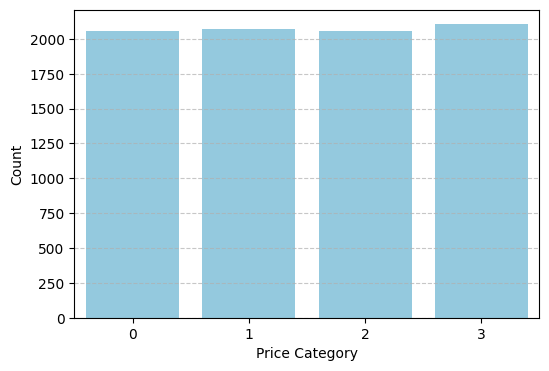

In [23]:
#response variable

plt.figure(figsize=(6,4))
sns.countplot(x=Y_train, color='skyblue')
plt.xlabel('Price Category')   
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Univariate Analysis

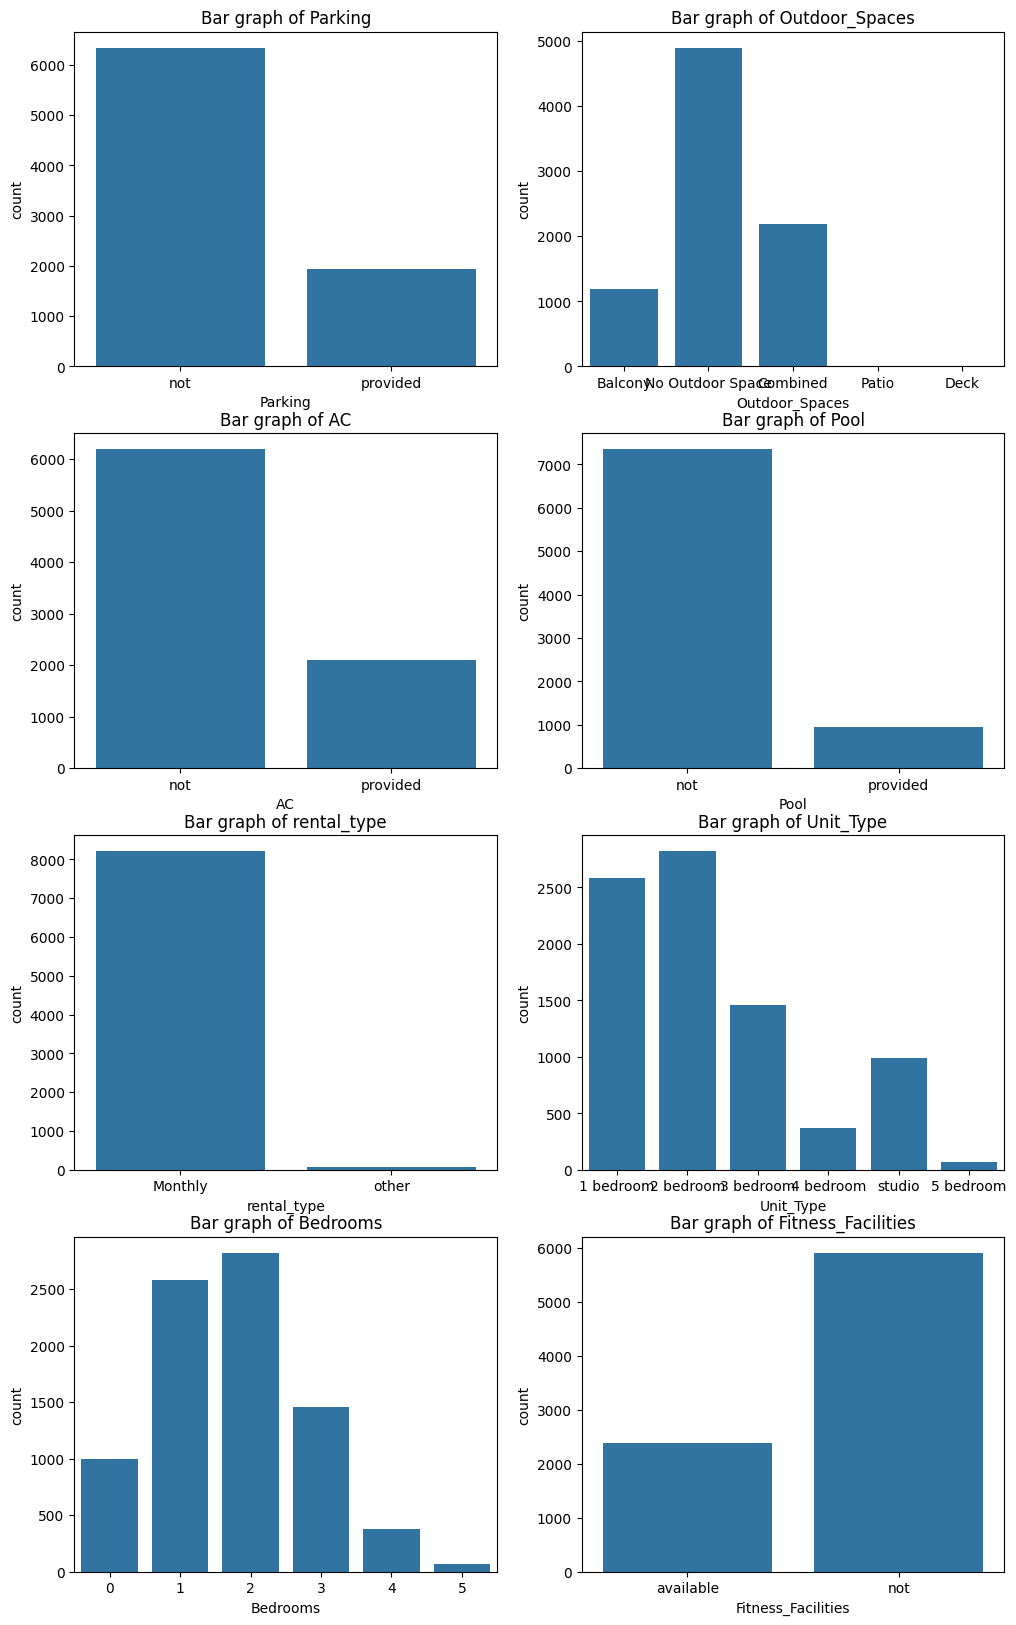

In [24]:
columns_to_plot = ['Parking','Outdoor_Spaces','AC','Pool','rental_type','Unit_Type','Bedrooms','Fitness_Facilities']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    sns.countplot(x=X_train[col], ax=axes[i])
    axes[i].set_title(f'Bar graph of {col}')
    

plt.show()

### Bivariate analysis

In [26]:
X_train.head(4)

,Parking,Flooring,Laundry,Dishwasher,Stainless_Appliances,Cable,Internet,Outdoor_Spaces,AC,Pool,...,State,City,rental_type,Price,Unit_Type,Bedrooms,city_clean,state_clean,latitude,longitude
5343,not,other,provided,provided,provided,not,not,Balcony,not,not,...,CA,Los Angeles,Monthly,2497.5,1 bedroom,1,los angeles,ca,33.973093,-118.247896
2938,not,other,provided,not,not,not,not,No Outdoor Space,not,not,...,TX,San Antonio,Monthly,1595.0,2 bedroom,2,san antonio,tx,29.468525,-98.526352
4474,not,other,not,not,not,not,not,No Outdoor Space,not,not,...,TX,Austin,Monthly,1200.0,1 bedroom,1,austin,tx,30.210692,-97.942749
6659,not,other,not,provided,not,not,not,No Outdoor Space,provided,provided,...,TX,Farmers Branch,Monthly,1319.0,1 bedroom,1,farmers branch,tx,32.926567,-96.896092


In [27]:
STATE_COL = "state_clean"
CITY_COL  = "City"
UNIT_COL  = "Unit_Type"
TARGET_COL = "price_category"

train_plot_df = X_train.copy()
train_plot_df[TARGET_COL] = Y_train.values

def grouped_bar_from_crosstab(ct, title, xlabel, ylabel, legend_title="price_Category"): 
    x_labels = ct.index.astype(str).tolist()
    groups   = ct.columns.tolist()
    x = np.arange(len(x_labels))

    width = 0.8 / max(1, len(groups))  # total width ~0.8
    fig, ax = plt.subplots(figsize=(6,4))

    # Light -> dark palette with 4 shades (tweak as needed)
    palette = ["#efe5de", "#d7b9c7", "#b991b4", "#3b2b39"][:len(groups)]

    for i, g in enumerate(groups):
        ax.bar(x + i*width - 0.4 + width/2,
               ct[g].values,
               width=width,
               label=str(g),
               edgecolor="black",
               alpha=0.9,
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=0)
    ax.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

In [28]:
train_plot_df['City']

5343        Los Angeles
2938        San Antonio
4474             Austin
6659     Farmers Branch
2343            Orlando
              ...      
11787           Chicago
5375             Dallas
5588        Bakersfield
883       San Francisco
7567              Eagan
Name: City, Length: 8290, dtype: object

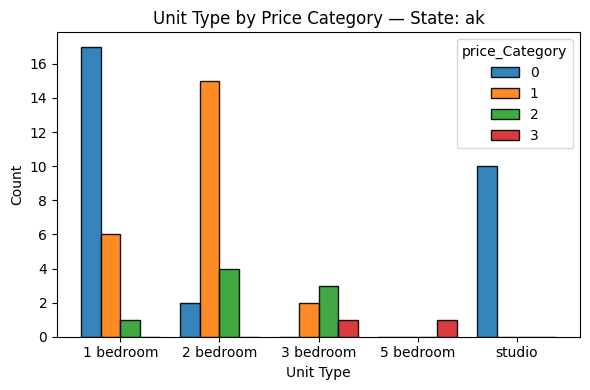

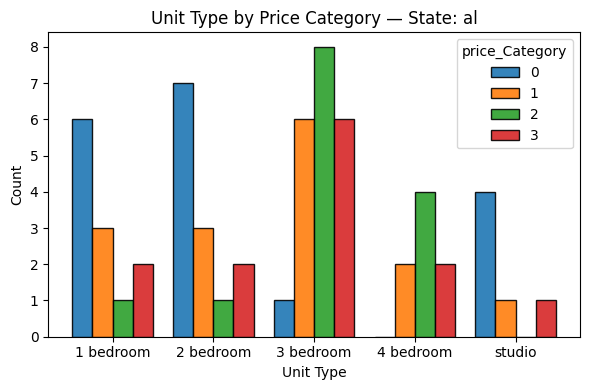

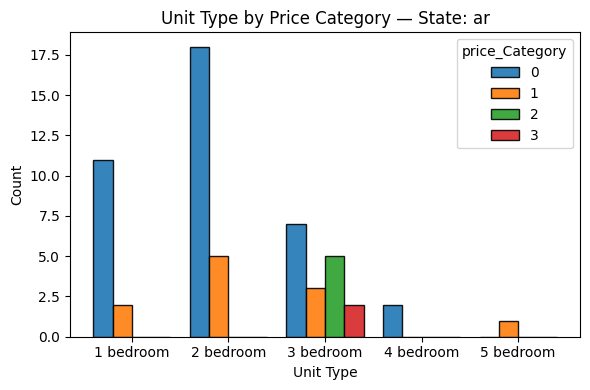

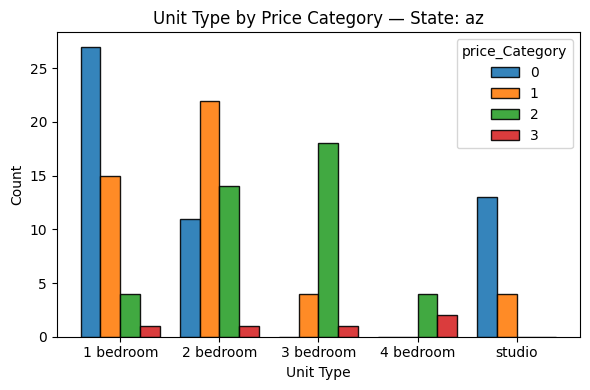

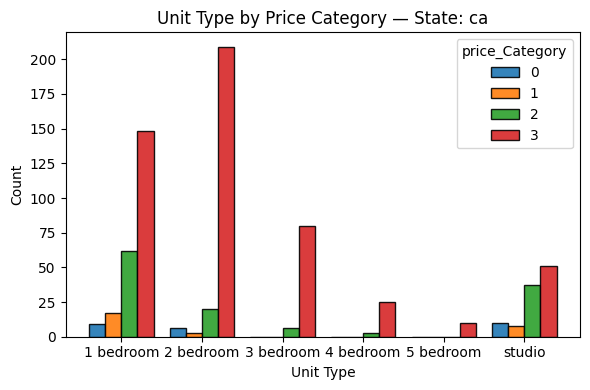

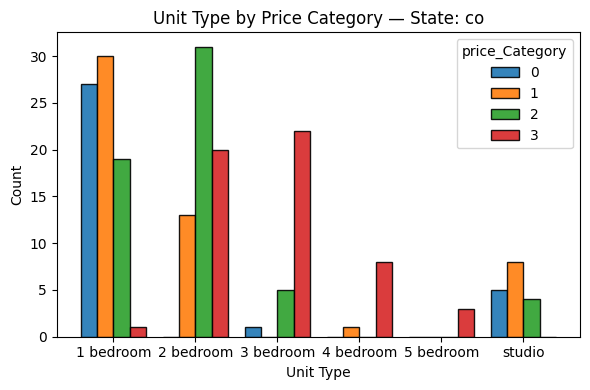

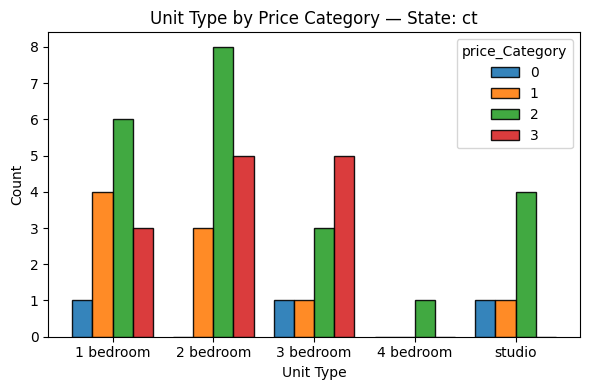

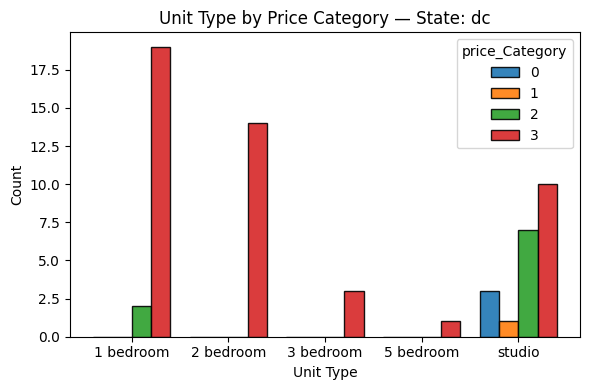

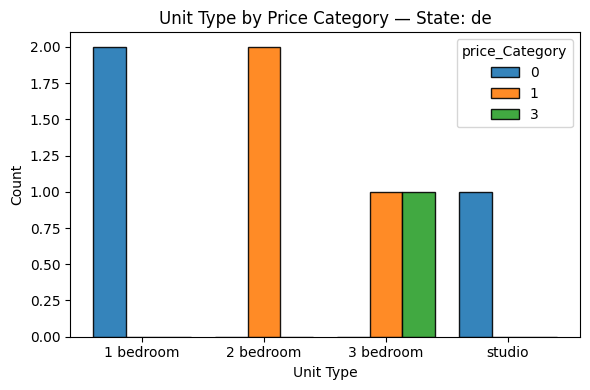

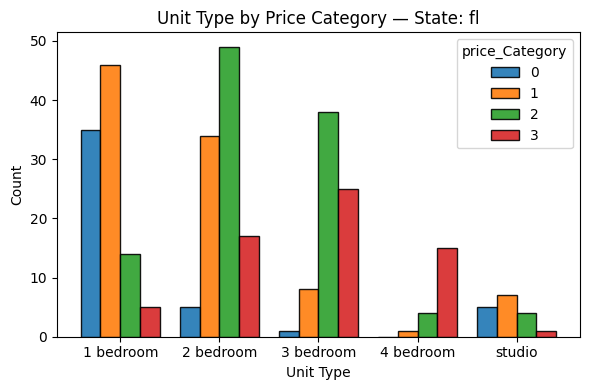

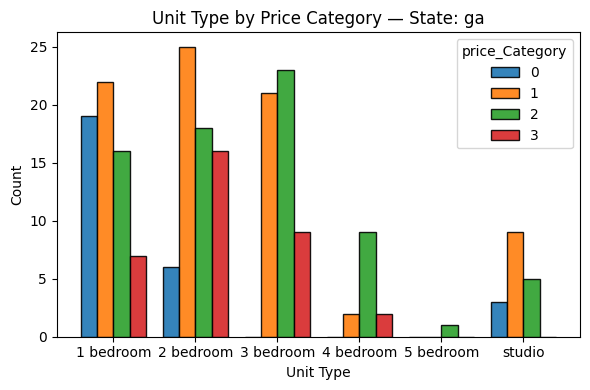

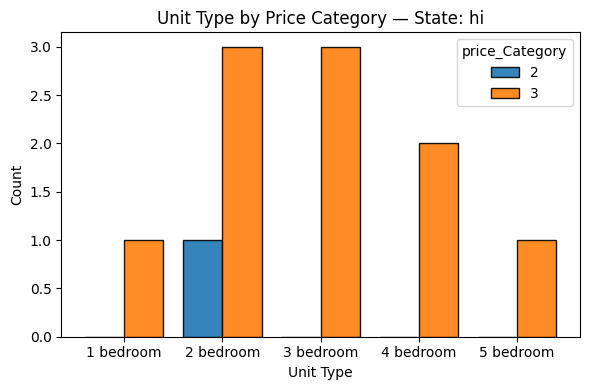

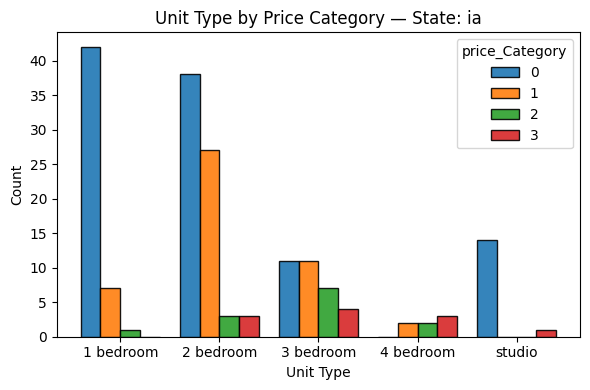

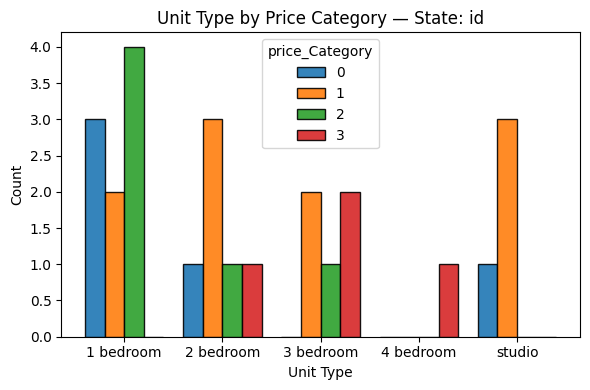

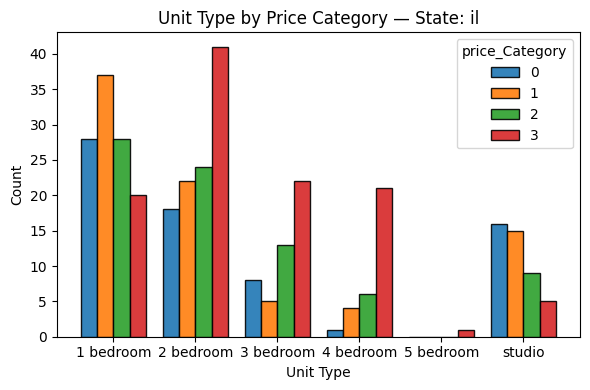

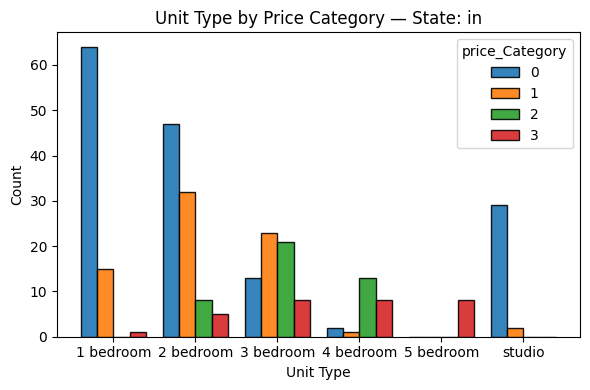

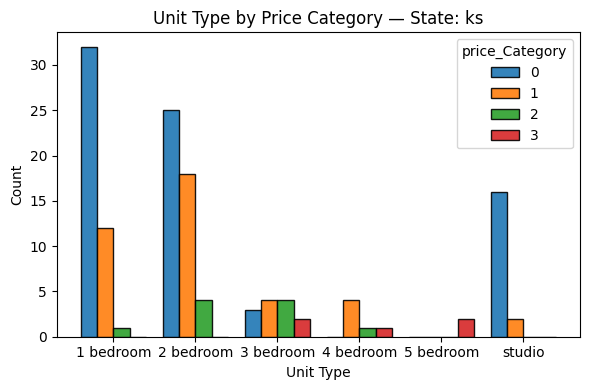

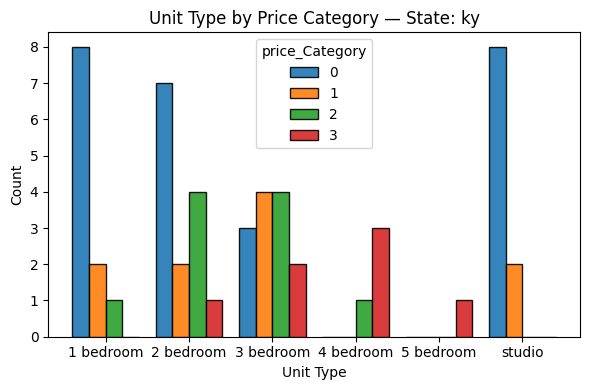

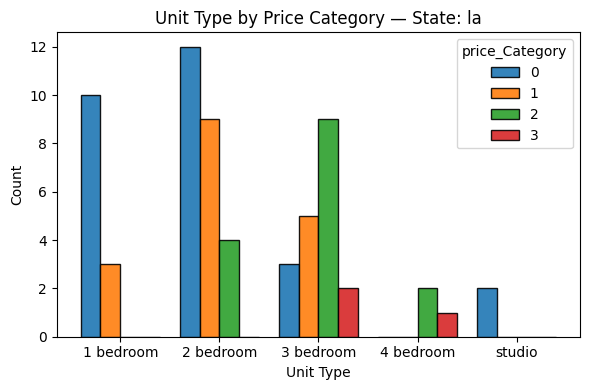

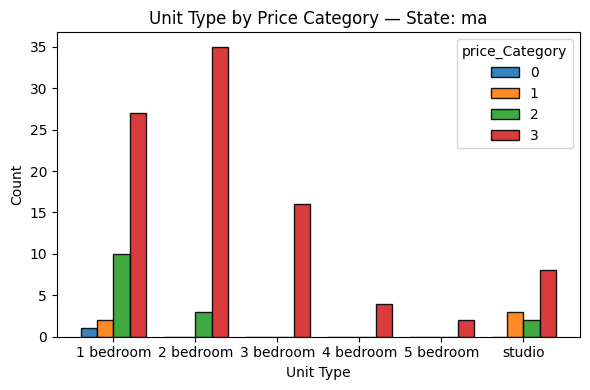

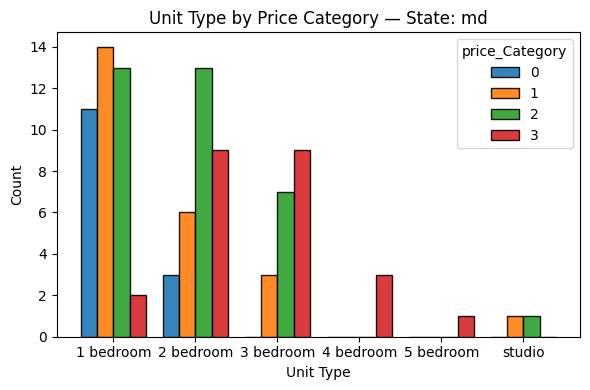

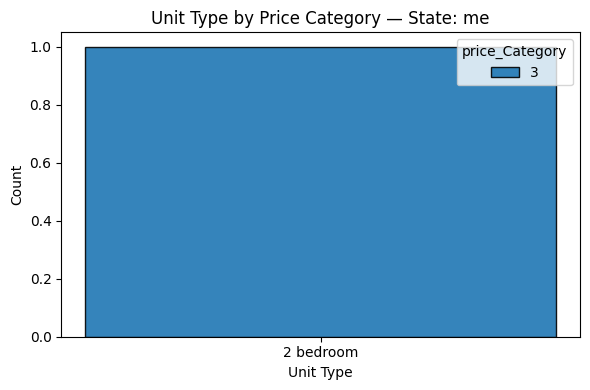

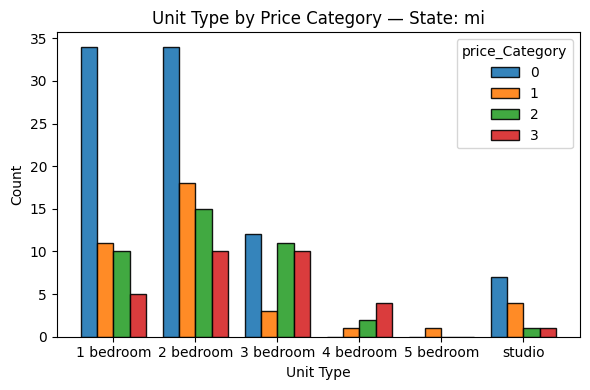

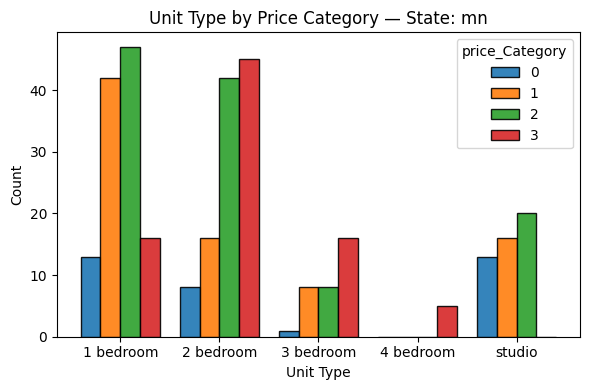

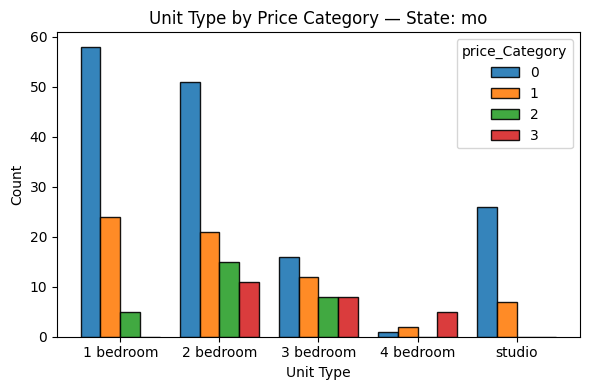

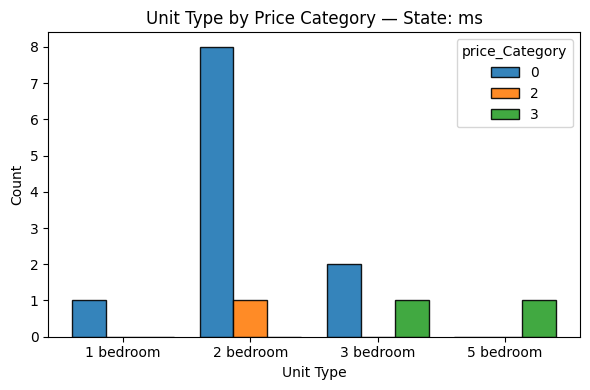

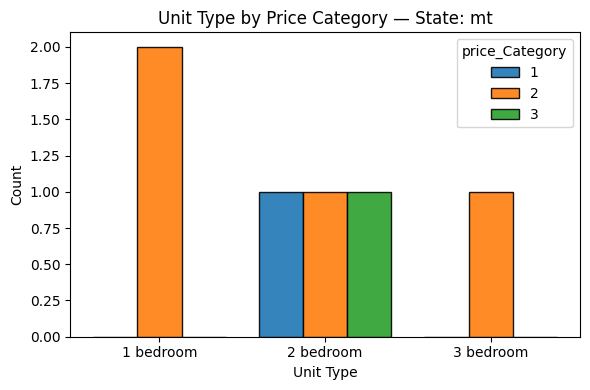

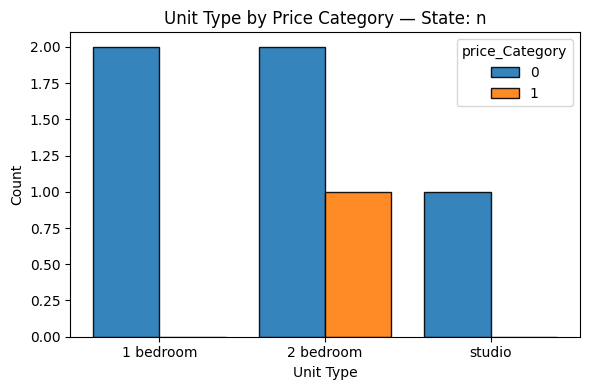

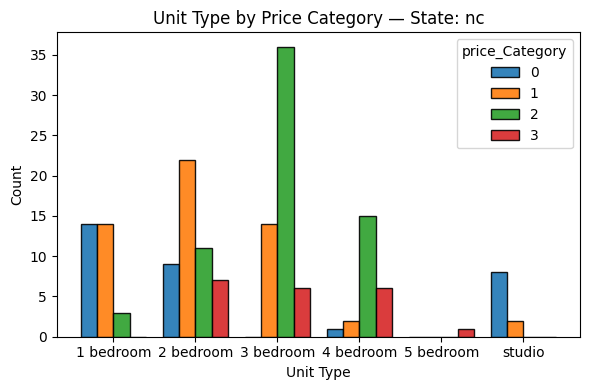

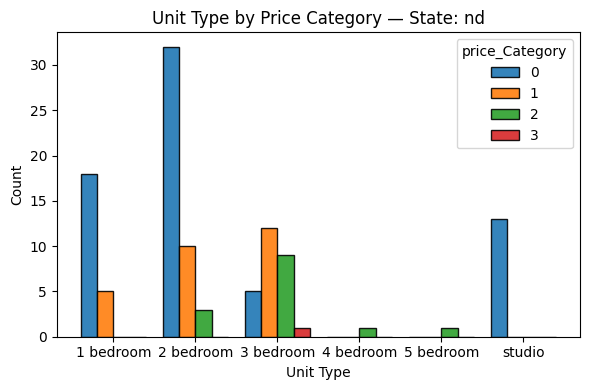

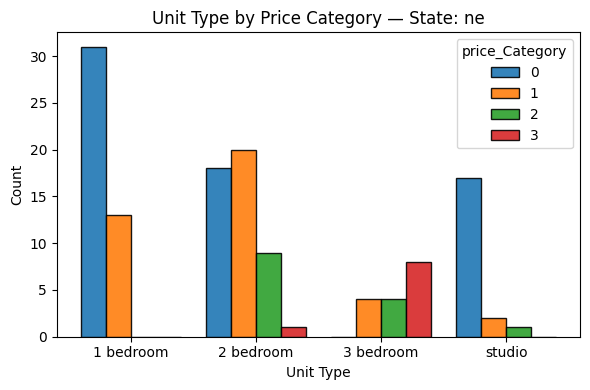

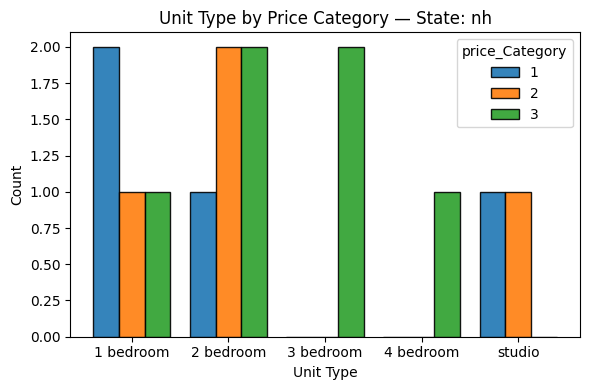

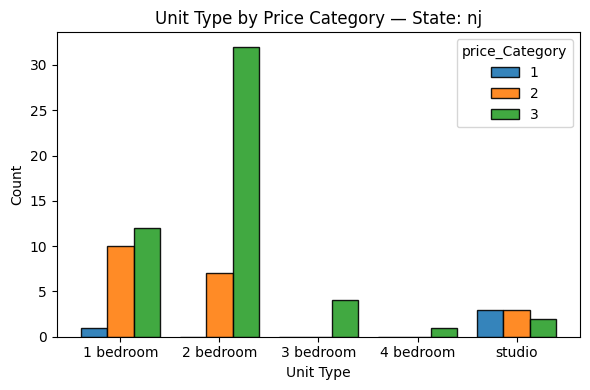

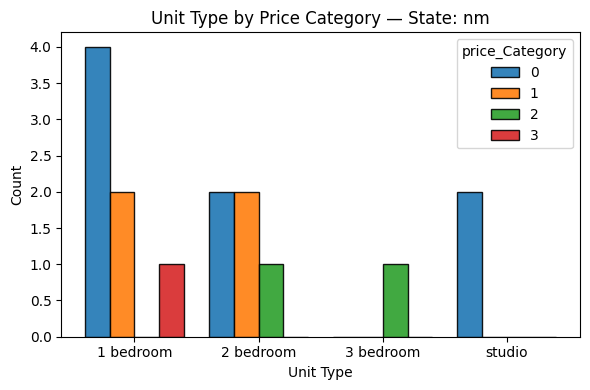

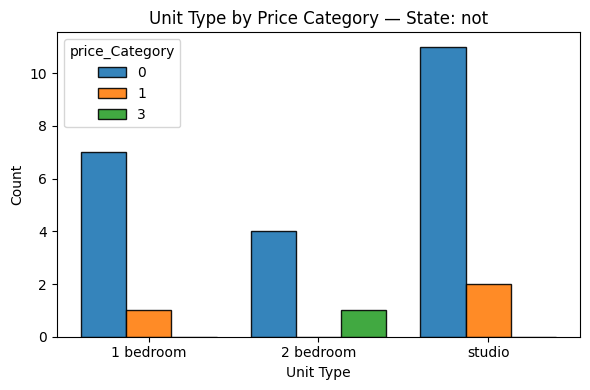

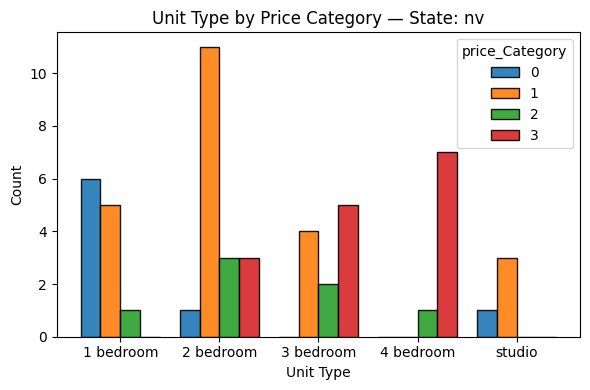

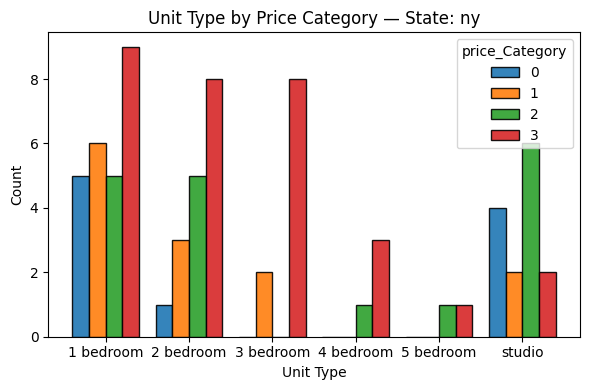

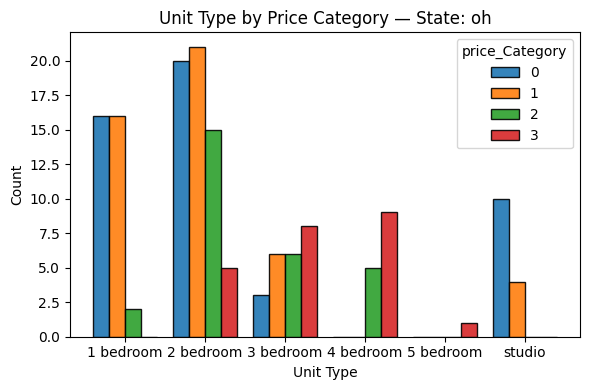

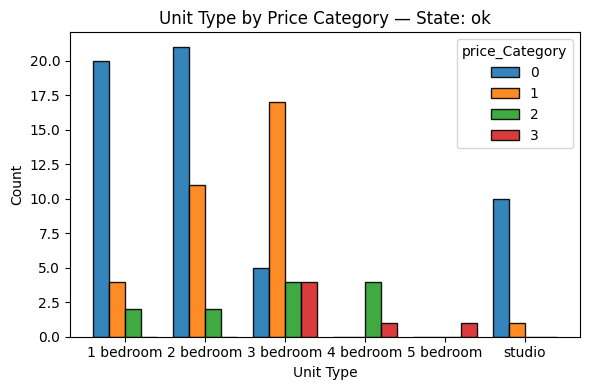

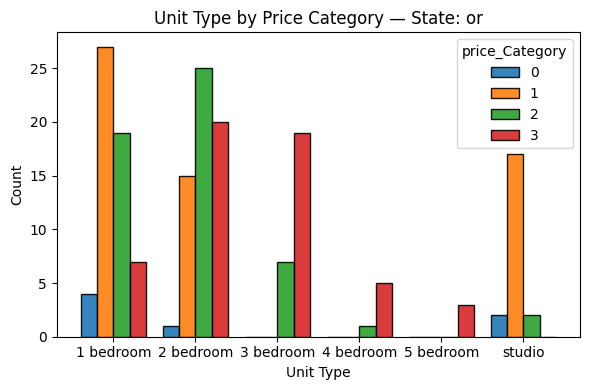

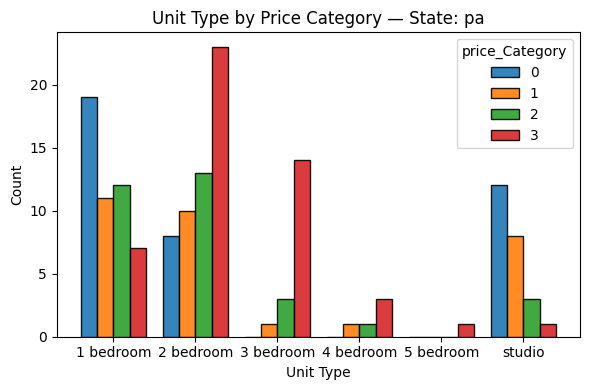

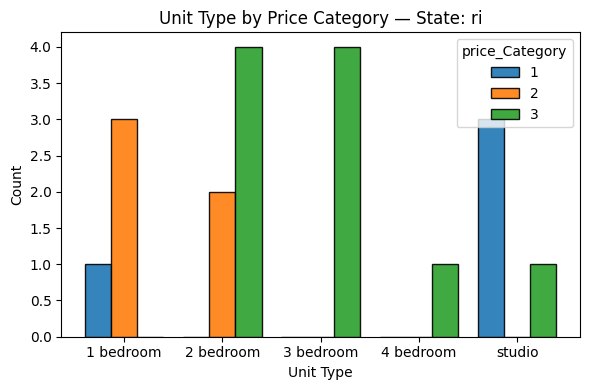

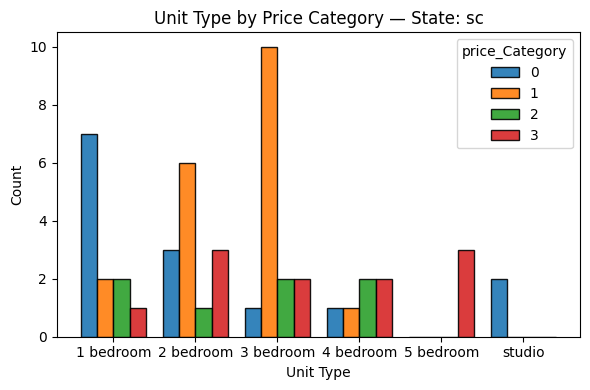

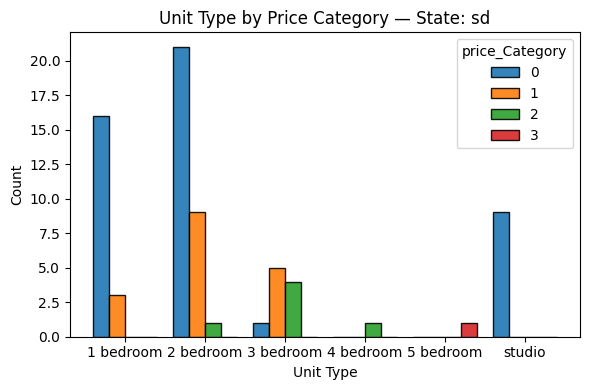

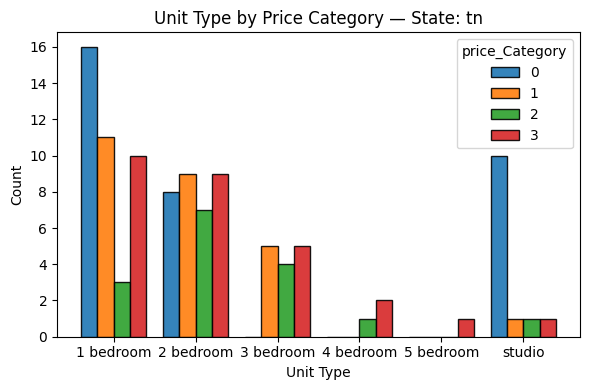

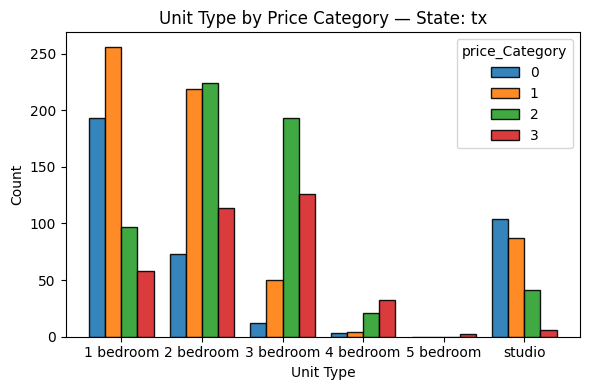

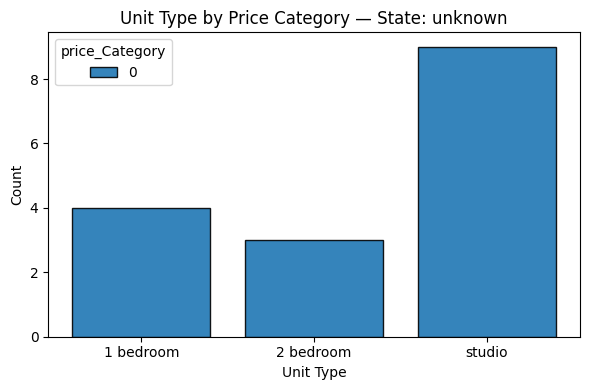

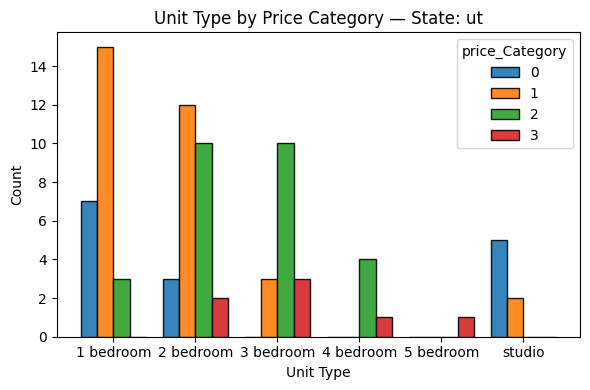

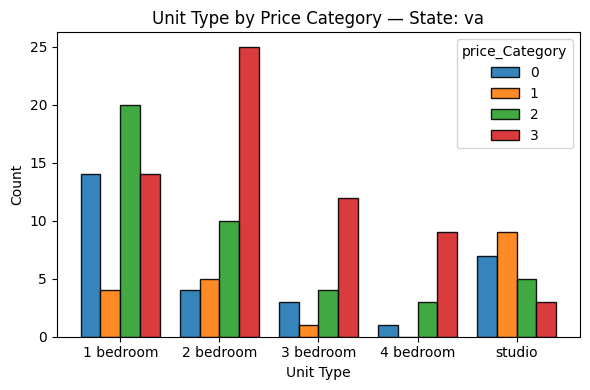

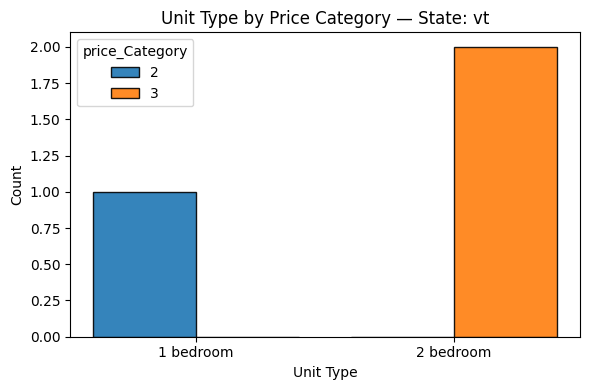

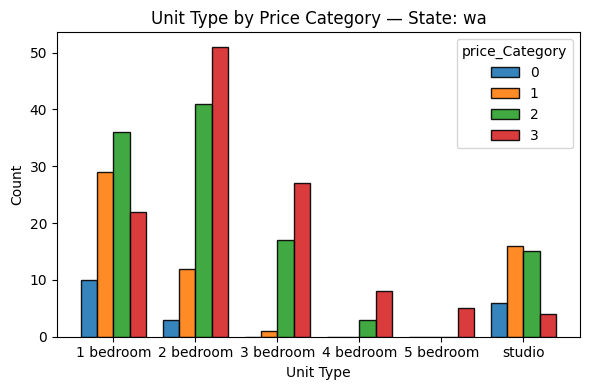

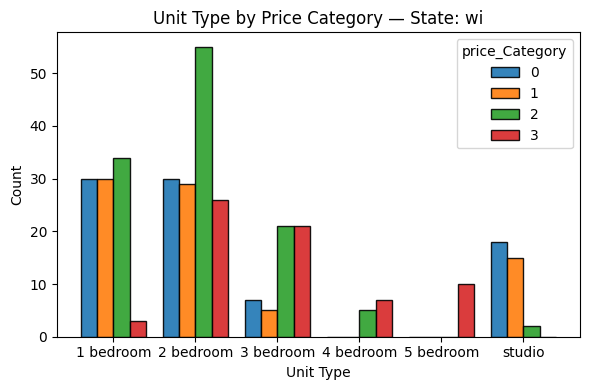

In [29]:
for st, g in train_plot_df.groupby(STATE_COL):
    ct = pd.crosstab(g[UNIT_COL], g[TARGET_COL])   # counts
    grouped_bar_from_crosstab(
        ct.sort_index(),
        title=f"Unit Type by Price Category — State: {st}",
        xlabel="Unit Type",
        ylabel="Count",
        legend_title="price_Category"
    )



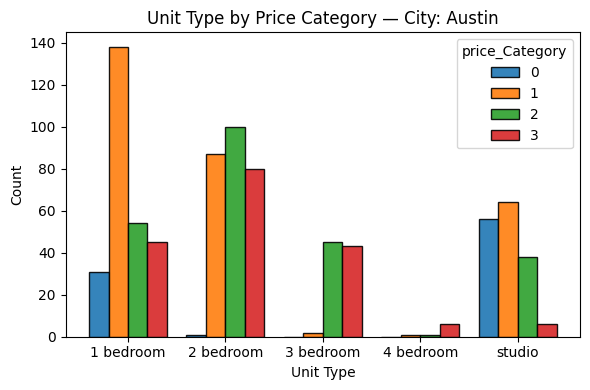

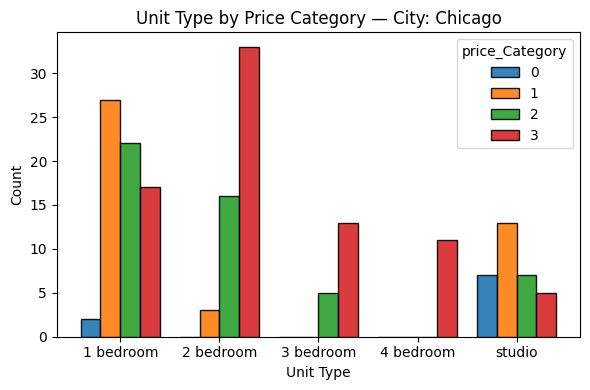

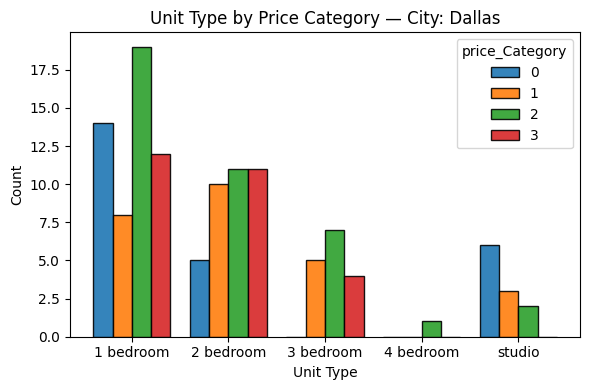

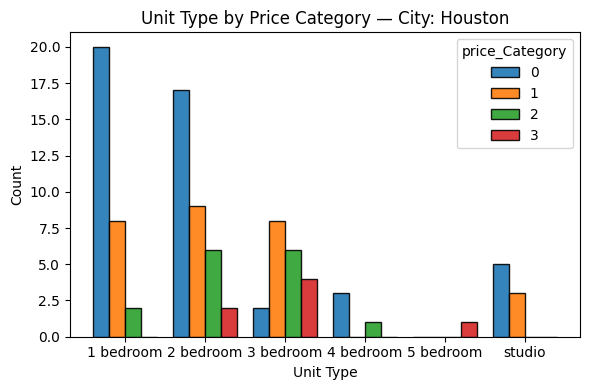

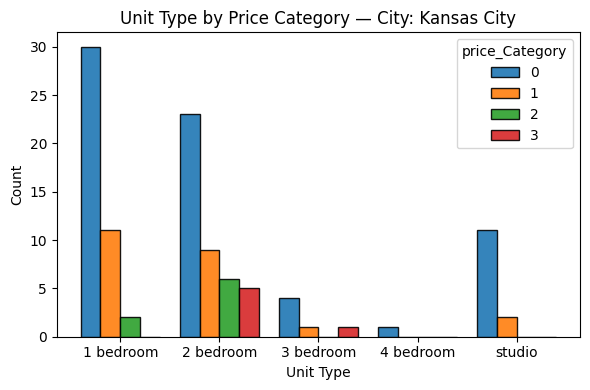

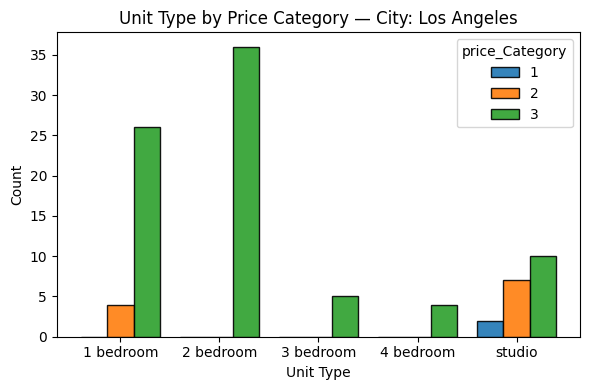

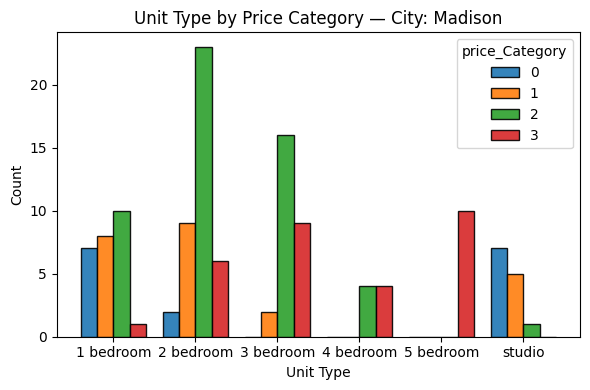

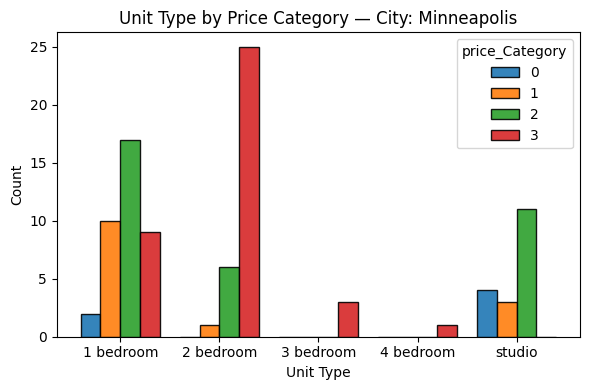

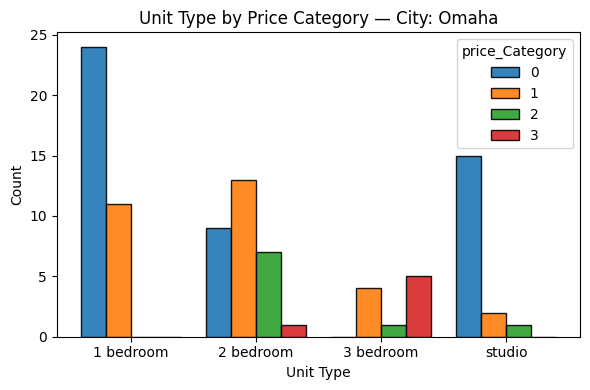

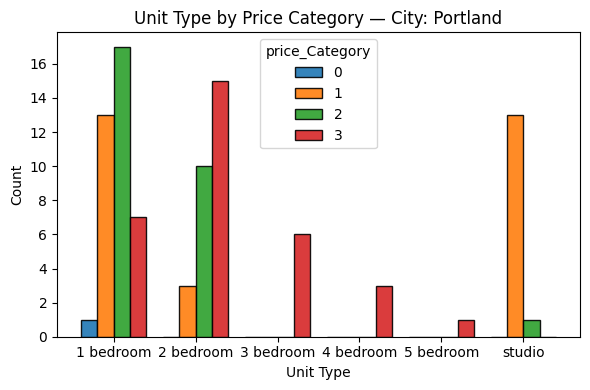

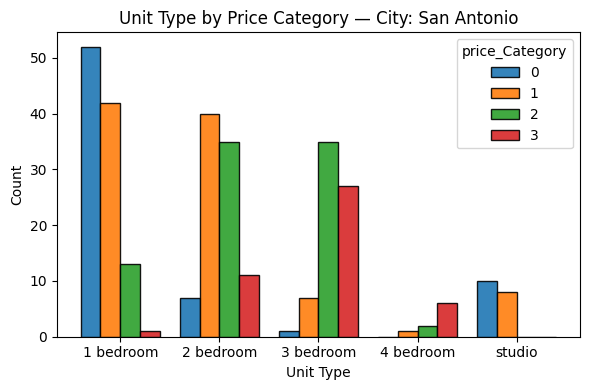

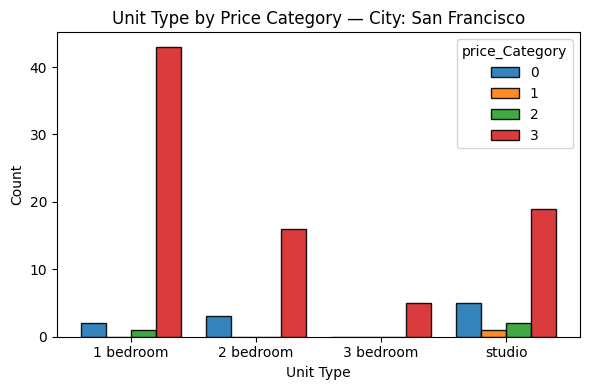

In [30]:
N = 12
top_cities = train_plot_df[CITY_COL].value_counts().head(N).index

for city, g in train_plot_df[train_plot_df[CITY_COL].isin(top_cities)].groupby(CITY_COL):
    ct = pd.crosstab(g[UNIT_COL], g[TARGET_COL])
    grouped_bar_from_crosstab(
        ct.sort_index(),
        title=f"Unit Type by Price Category — City: {city}",
        xlabel="Unit Type",
        ylabel="Count",
        legend_title="price_Category"
    )



In [38]:
from scipy.stats import chi2_contingency

# config
TARGET_COL = TARGET_COL  # already defined in your notebook

cats = train_plot_df.select_dtypes(include=["object","category"]).columns
rows = []

for col in cats:
    if col == TARGET_COL:
        continue
    if train_plot_df[col].nunique() > 50:
        continue

    ct = pd.crosstab(train_plot_df[col], train_plot_df[TARGET_COL])

    # Chi-square test (Yates correction applies automatically for 2x2; set correction=False if you don't want it)
    chi2, p, dof, _ = chi2_contingency(ct)  # or chi2_contingency(ct, correction=False)

    rows.append((col, train_plot_df[col].nunique(), chi2, p, dof))

chi_res = (
    pd.DataFrame(rows, columns=["feature", "n_levels", "chi2", "p_value", "dof"])
      .sort_values(["p_value", "chi2"], ascending=[True, False])
      .reset_index(drop=True)
)

chi_res.head(20)


,feature,n_levels,chi2,p_value,dof
0,Unit_Type,6,1353.799925,1.433976e-279,15
1,Bedrooms,6,1353.799925,1.433976e-279,15
2,Flooring,4,236.653402,6.522869e-46,9
3,rental_type,2,166.894786,5.956599e-36,3
4,Laundry,2,117.803212,2.293596e-25,3
5,AC,2,81.083110,1.797596e-17,3
6,Outdoor_Spaces,5,101.411870,2.943742e-16,12
7,Dishwasher,2,53.837433,1.215305e-11,3
8,Cable,2,44.639155,1.103951e-09,3
9,Fitness_Facilities,2,43.756947,1.699686e-09,3


In [32]:
TARGET_COL = "price_category"

#  Start from all categorical-like vars (skip target, very high-cardinality)
cat_vars = [c for c in train_plot_df.select_dtypes(include=["object","category"]).columns
            if c != TARGET_COL and 2 <= train_plot_df[c].nunique() <= 30]

#  Add binned versions of numeric columns here
NUMERIC_TO_BIN = ["bedrooms", "bathrooms", "area", "sqft", "age"]  # edit to your columns
for col in NUMERIC_TO_BIN:
    if col in train_plot_df.columns:
        # create 5 quantile bins; dropna handled implicitly
        try:
            train_plot_df[col + "_bin"] = pd.qcut(train_plot_df[col], q=5, duplicates="drop")
            cat_vars.append(col + "_bin")
        except Exception:
            pass  # skip if not enough unique values

# Final variable list 
seen, VARS = set(), []
for v in cat_vars:
    if v not in seen:
        VARS.append(v); seen.add(v)

VARS

['Parking',
 'Flooring',
 'Laundry',
 'Dishwasher',
 'Stainless_Appliances',
 'Cable',
 'Internet',
 'Outdoor_Spaces',
 'AC',
 'Pool',
 'Fitness_Facilities',
 'rental_type',
 'Unit_Type',
 'Bedrooms']

In [33]:
def plot_top_levels_within_tier(g, var, top_k=10, as_percent=True):
    """
    g: subset of train_plot_df for a single price tier
    var: variable to analyze (categorical or binned numeric)
    top_k: show only top_k levels by count
    as_percent: plot % within the tier (True) or raw counts (False)
    """
    vc = g[var].value_counts(dropna=False)
    vc = vc.head(top_k)
    vals = (vc / vc.sum()) if as_percent else vc

    fig, ax = plt.subplots(figsize=(6,3.5))
    ax.bar(vals.index.astype(str), vals.values, edgecolor="black")
    title = f"{var} — price_category = {g[TARGET_COL].iloc[0]}"
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel("Share within tier" if as_percent else "Count")
    ax.set_xticklabels(vals.index.astype(str), rotation=0)
    plt.tight_layout()
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


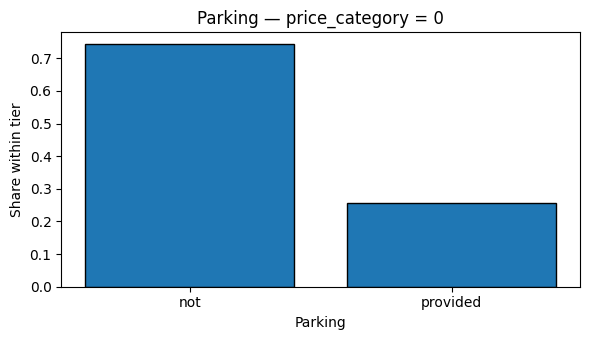

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


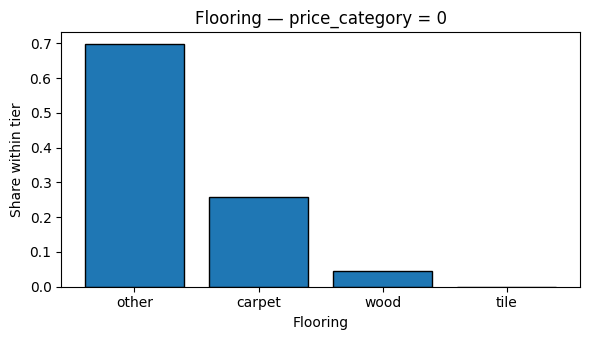

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


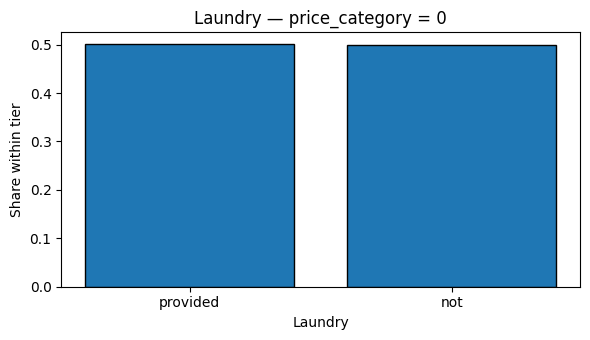

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


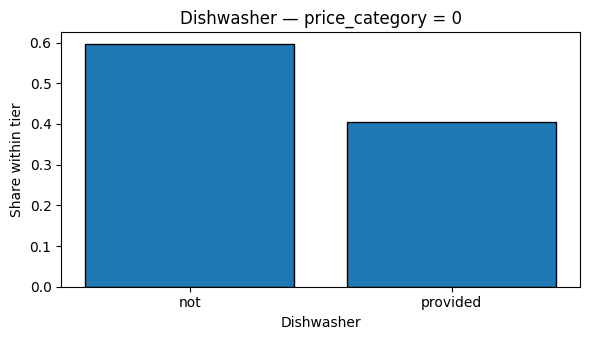

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


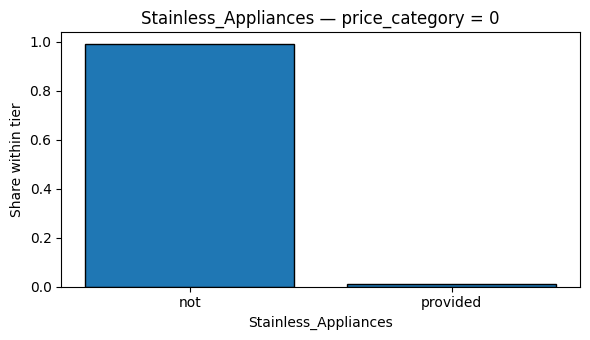

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


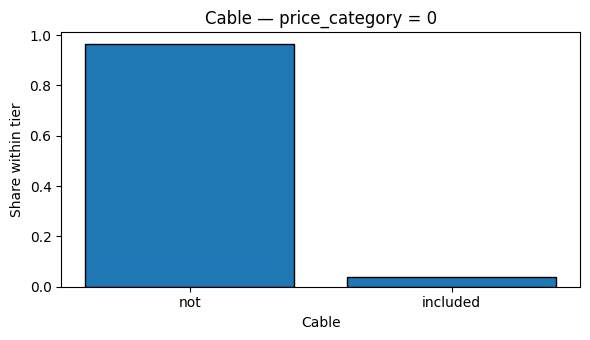

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


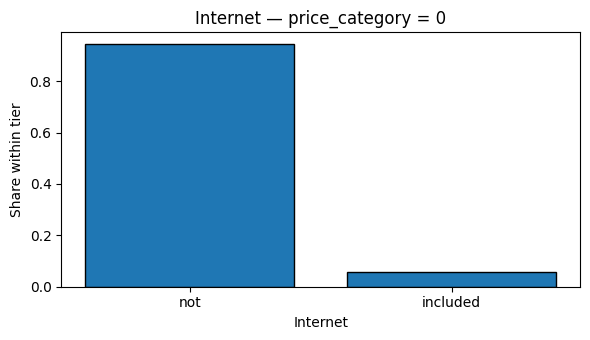

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


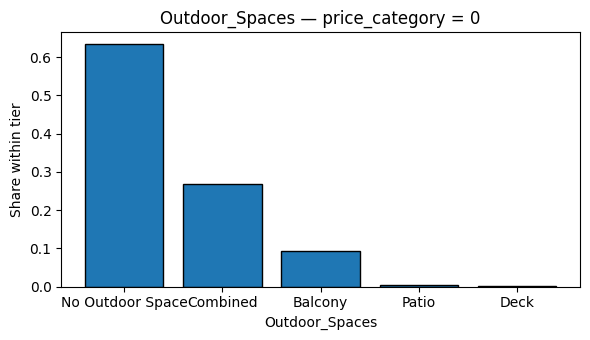

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


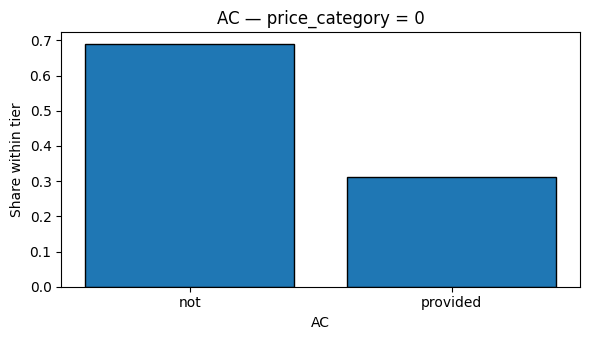

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


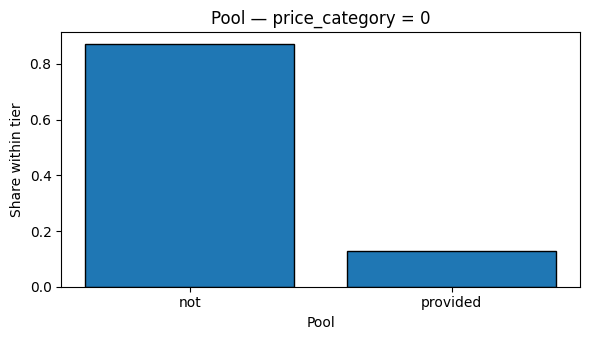

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


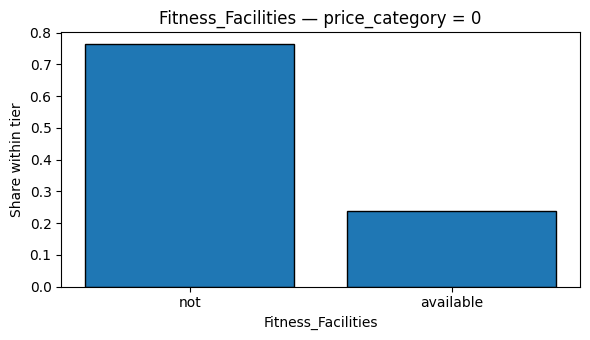

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


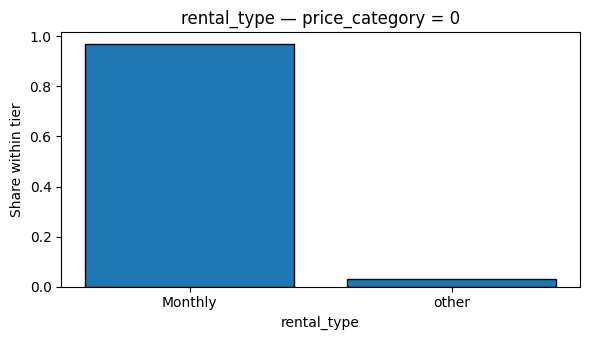

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


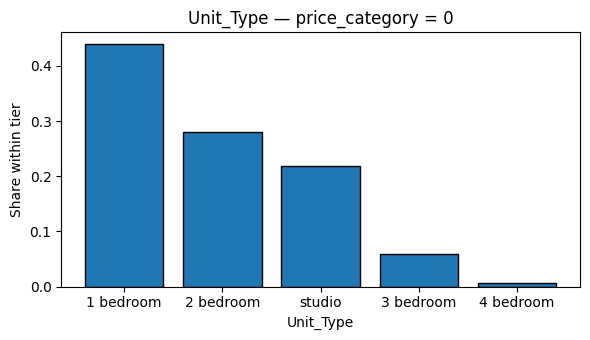

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


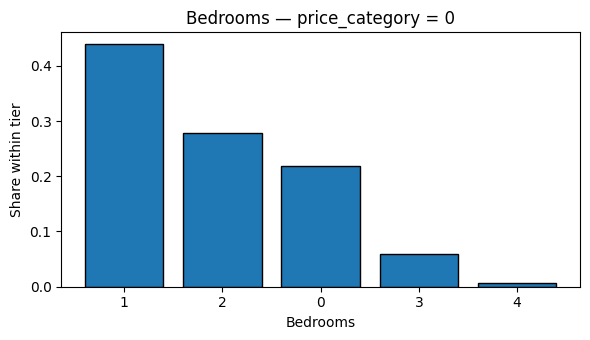

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


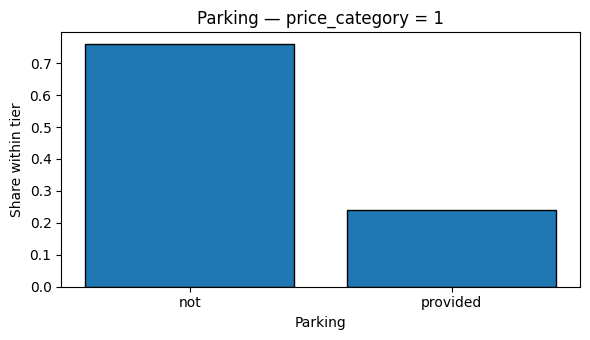

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


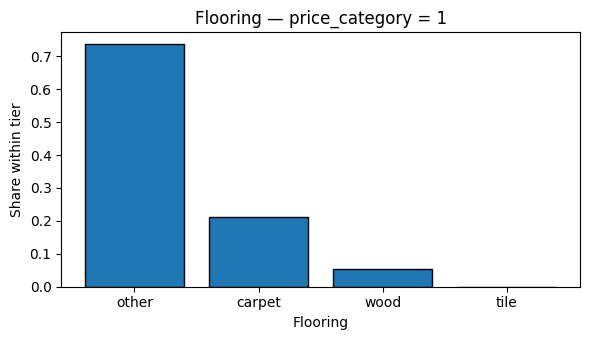

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


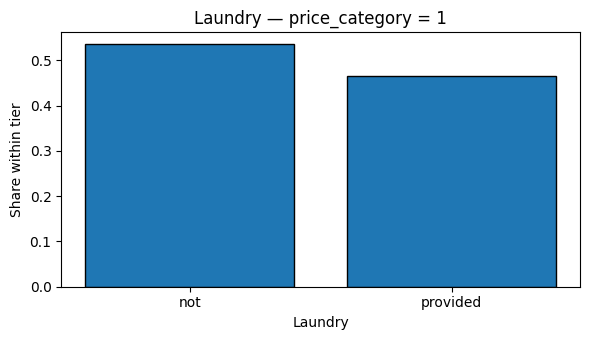

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


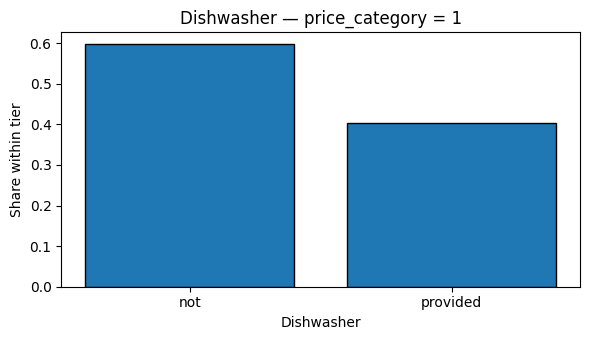

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


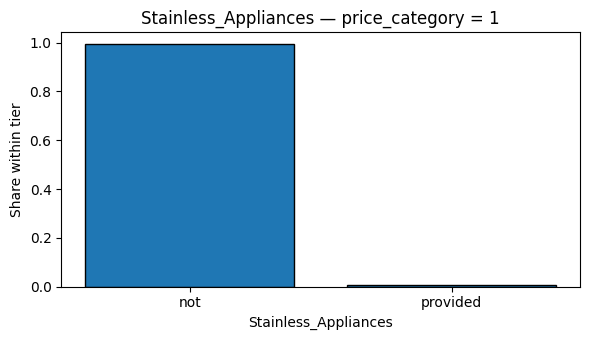

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


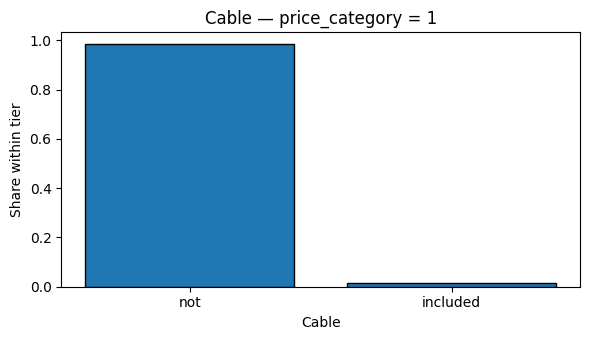

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


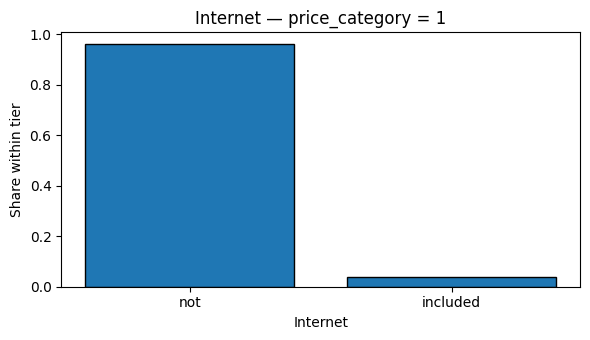

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


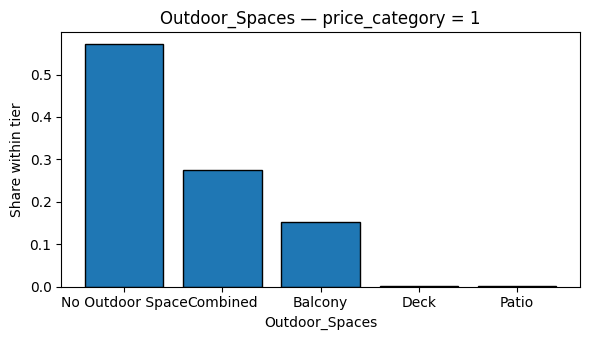

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


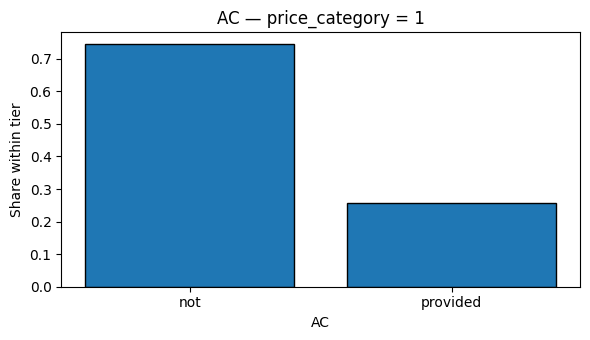

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


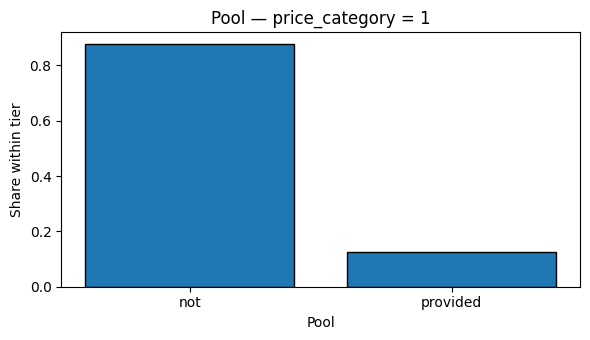

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


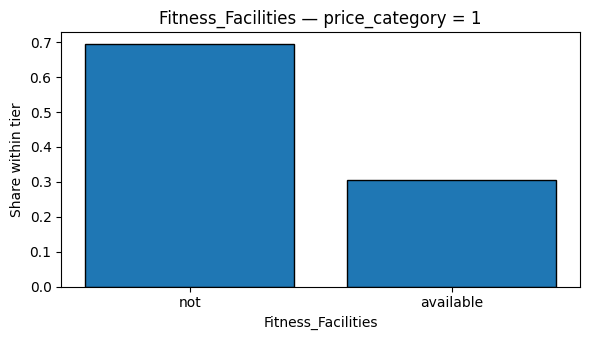

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


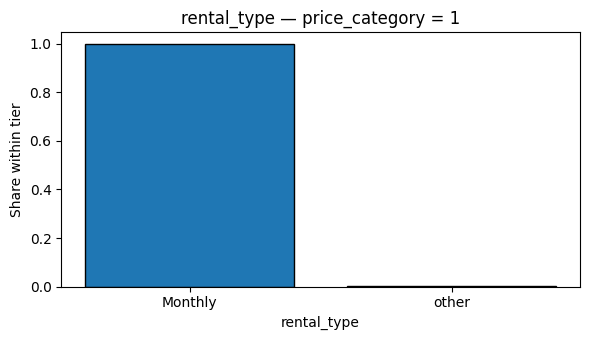

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


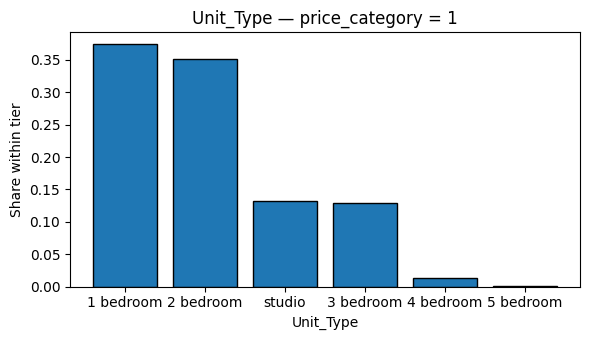

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


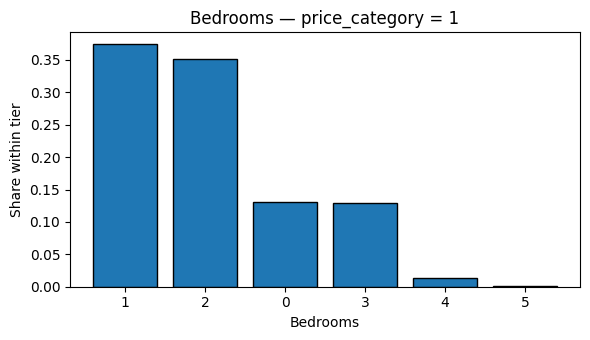

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


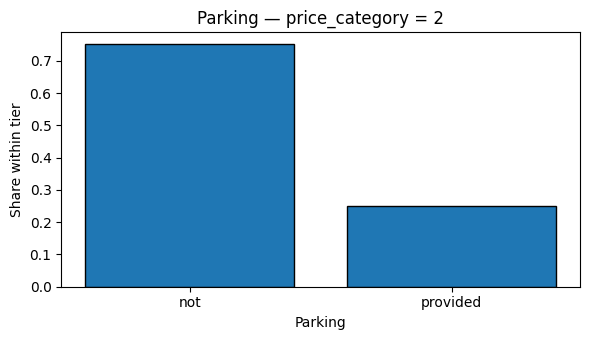

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


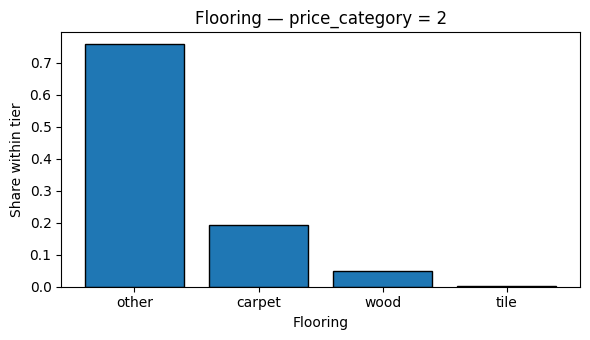

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


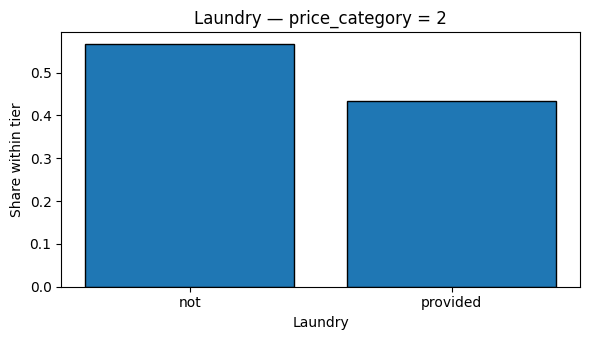

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


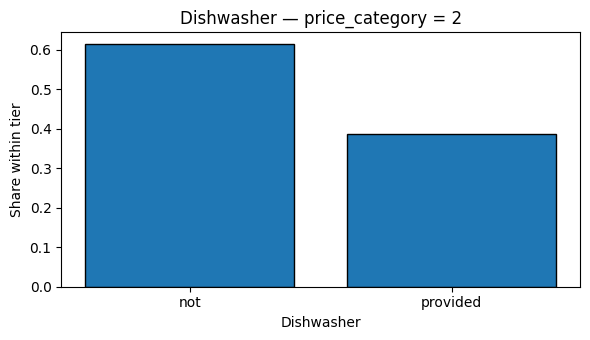

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


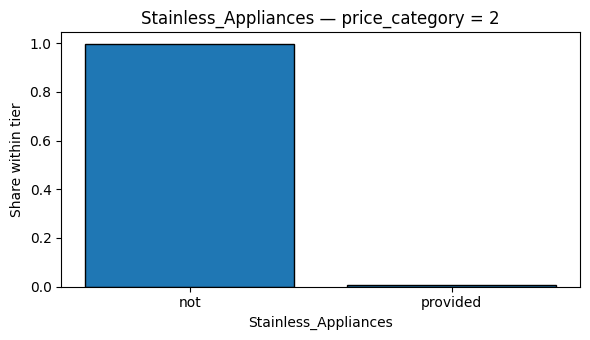

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


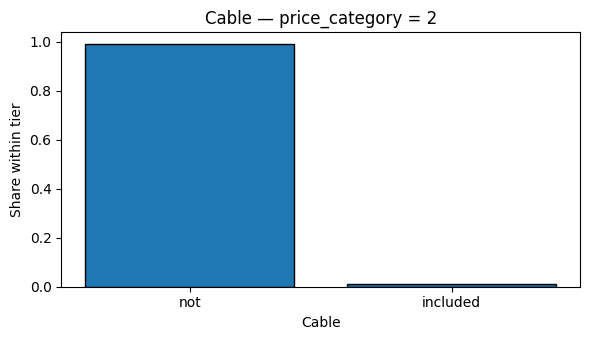

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


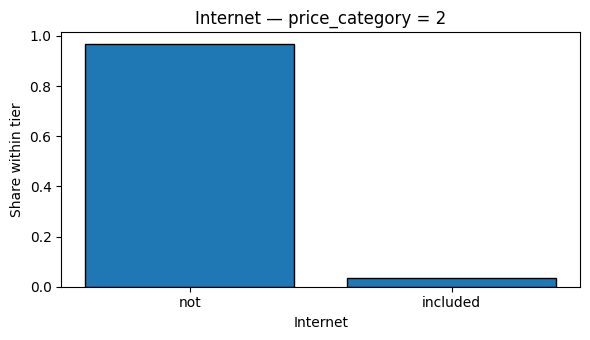

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


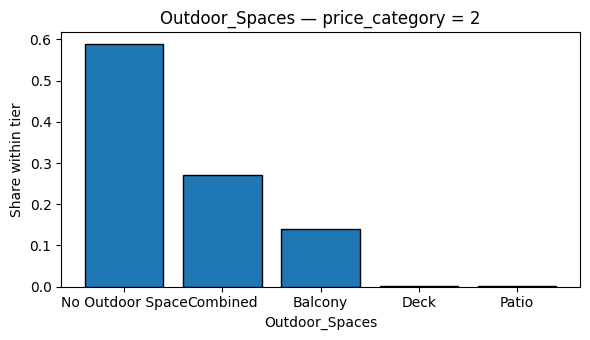

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


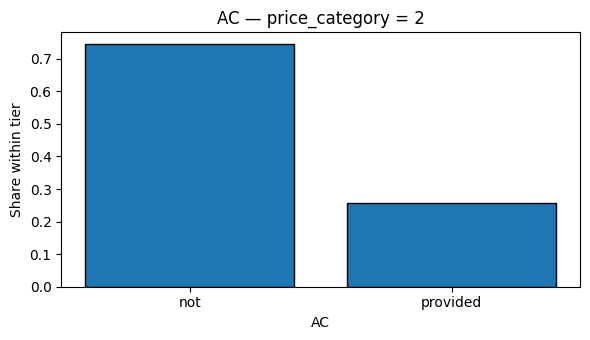

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


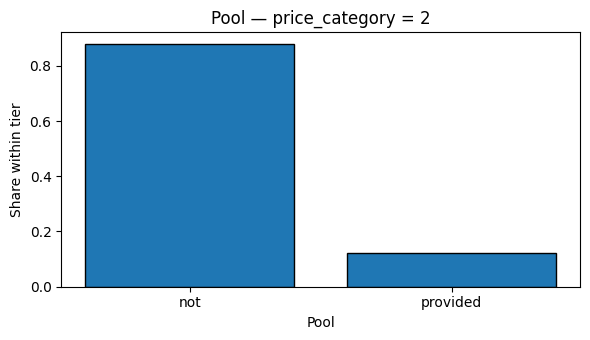

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


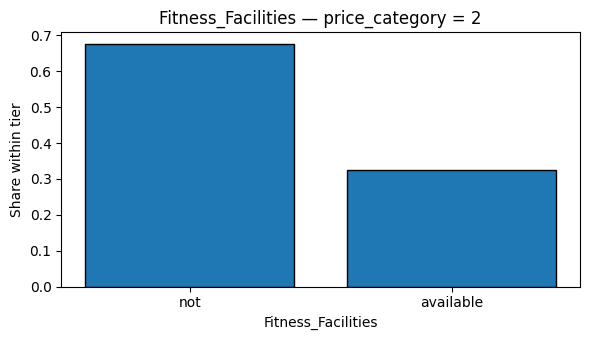

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


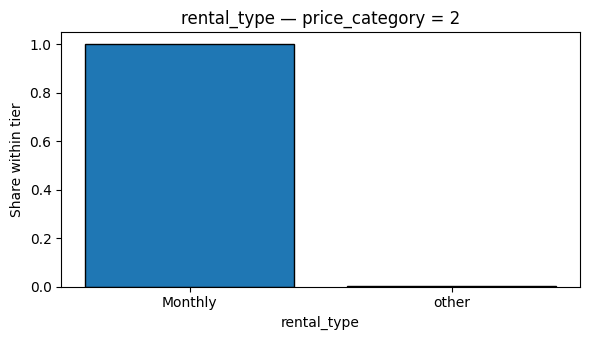

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


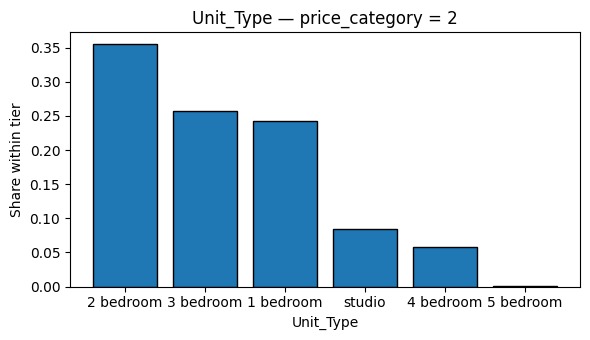

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


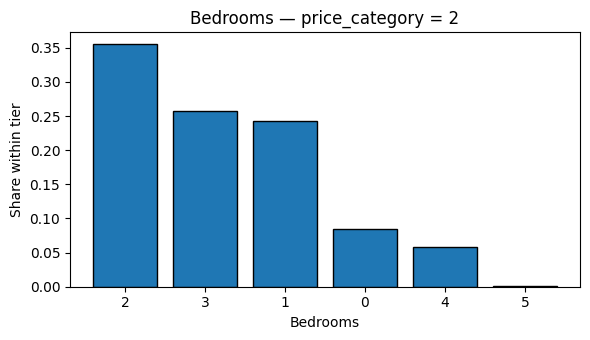

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


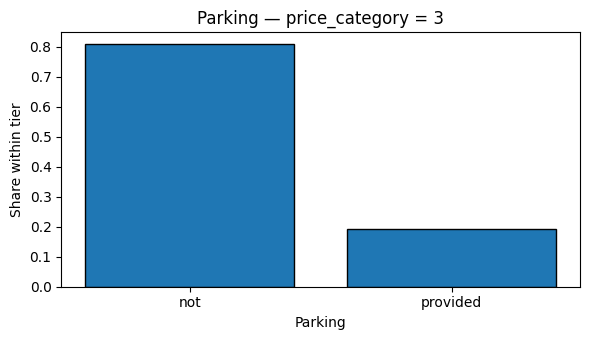

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


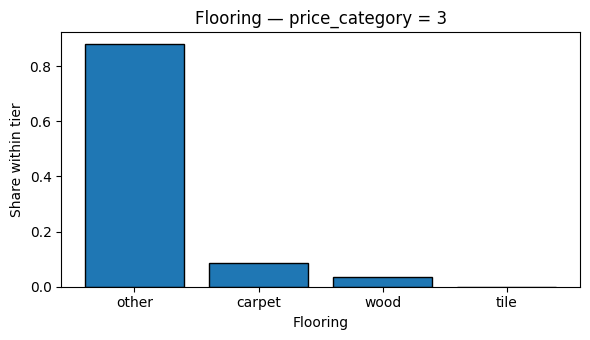

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


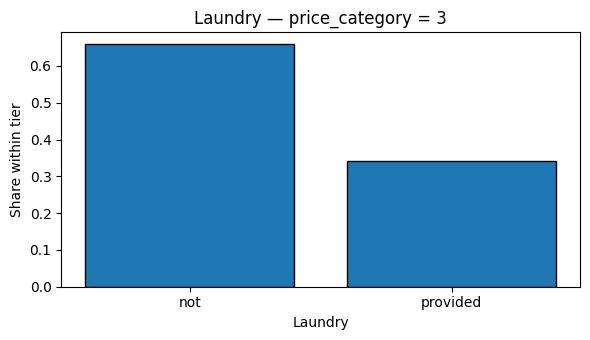

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


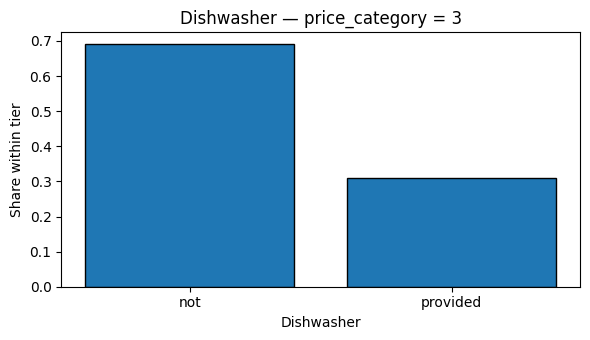

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


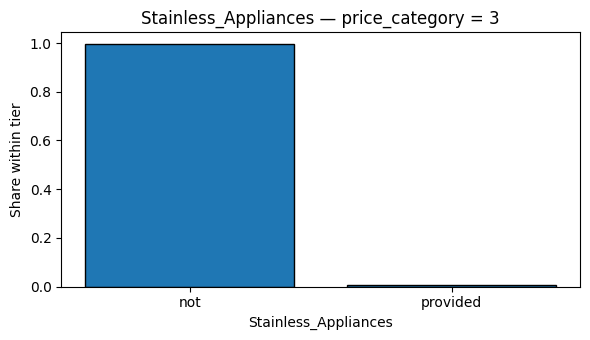

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


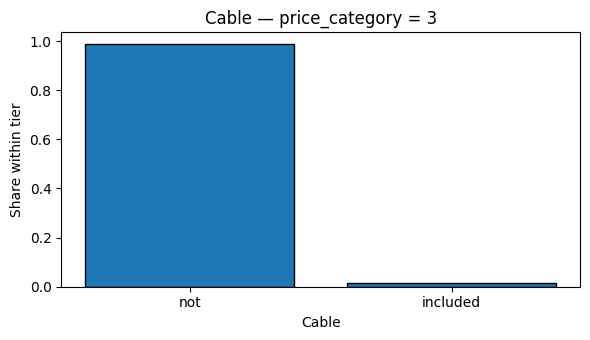

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


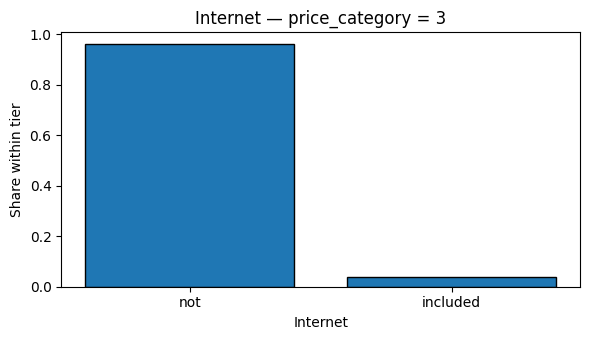

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


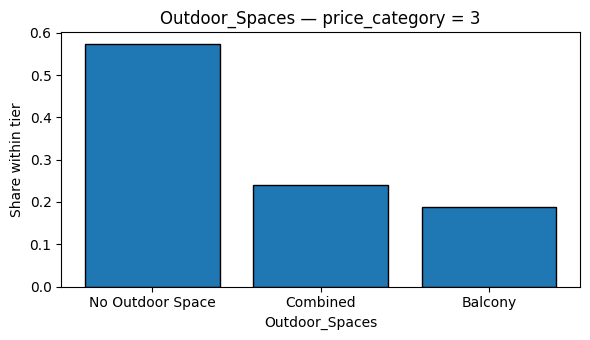

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


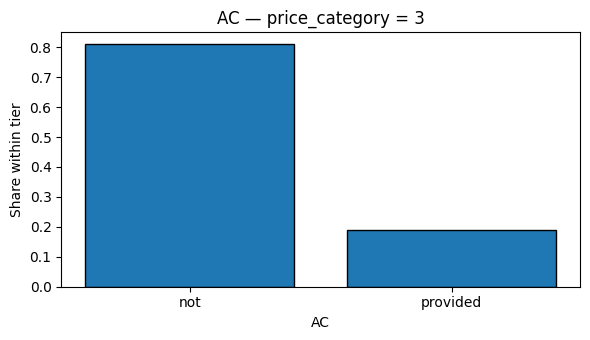

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


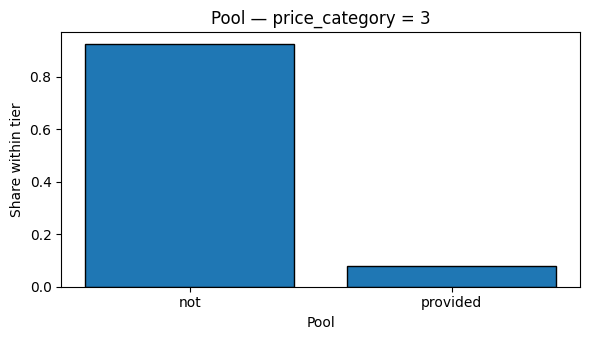

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


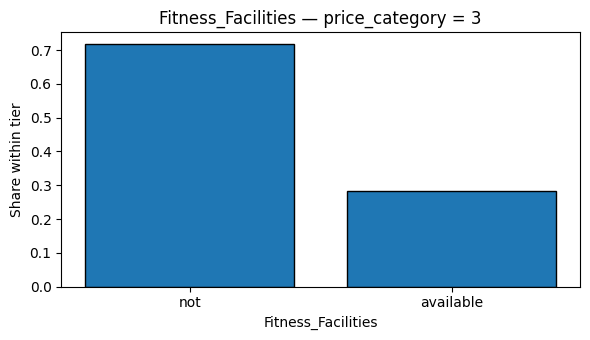

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


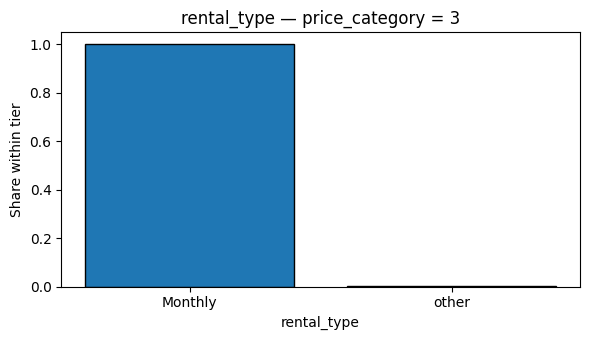

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


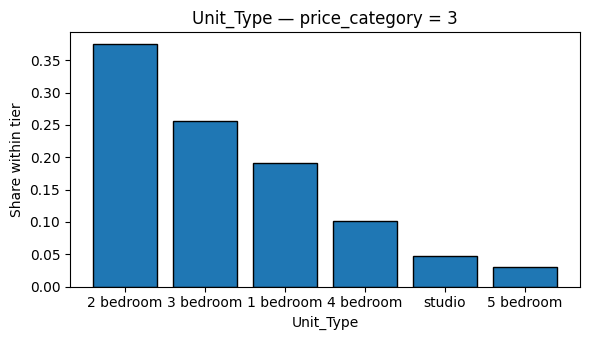

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\1408272460.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index.astype(str), rotation=0)


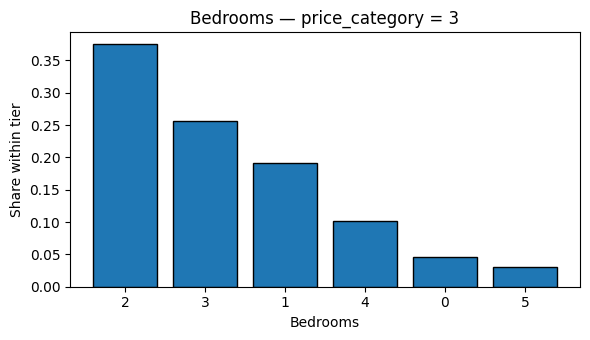

In [34]:
TOP_K = 10       # show top 10 levels per variable for readability
AS_PERCENT = True  # show share within the tier (set False for counts)

for pc, g in train_plot_df.groupby(TARGET_COL):
    for var in VARS:
        plot_top_levels_within_tier(g, var, top_k=TOP_K, as_percent=AS_PERCENT)
        plt.show()

--- 🏙 Average Rental Prices by City ---

💰 Top 10 Highest Rental Cities:
City
Key Biscayne           19750.000000
Menlo Park              8200.000000
Montecito               7200.000000
Kailua                  6716.666667
Annapolis               6500.000000
Brookline               6300.000000
Coronado                5728.571429
Dana Point              5500.000000
San Juan Capistrano     5499.000000
Beverly Hills           5490.550000
Name: Price, dtype: float64

💸 Top 10 Lowest Rental Cities:
City
Mount Airy             200.00000
Almeda                 100.00000
Thornbury              100.00000
Camden Woodson Park    100.00000
Cypress Falls          100.00000
Camden Park            100.00000
unknown                 90.47619
Fair Oaks                0.00000
Hollister                0.00000
Uvalde                   0.00000
Name: Price, dtype: float64


--- 🏞 Average Rental Prices by State ---

💰 Top 10 Highest Rental States:
State
HI    3605.307692
CA    2686.972445
MA    2611.496815
ME 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\3108115477.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


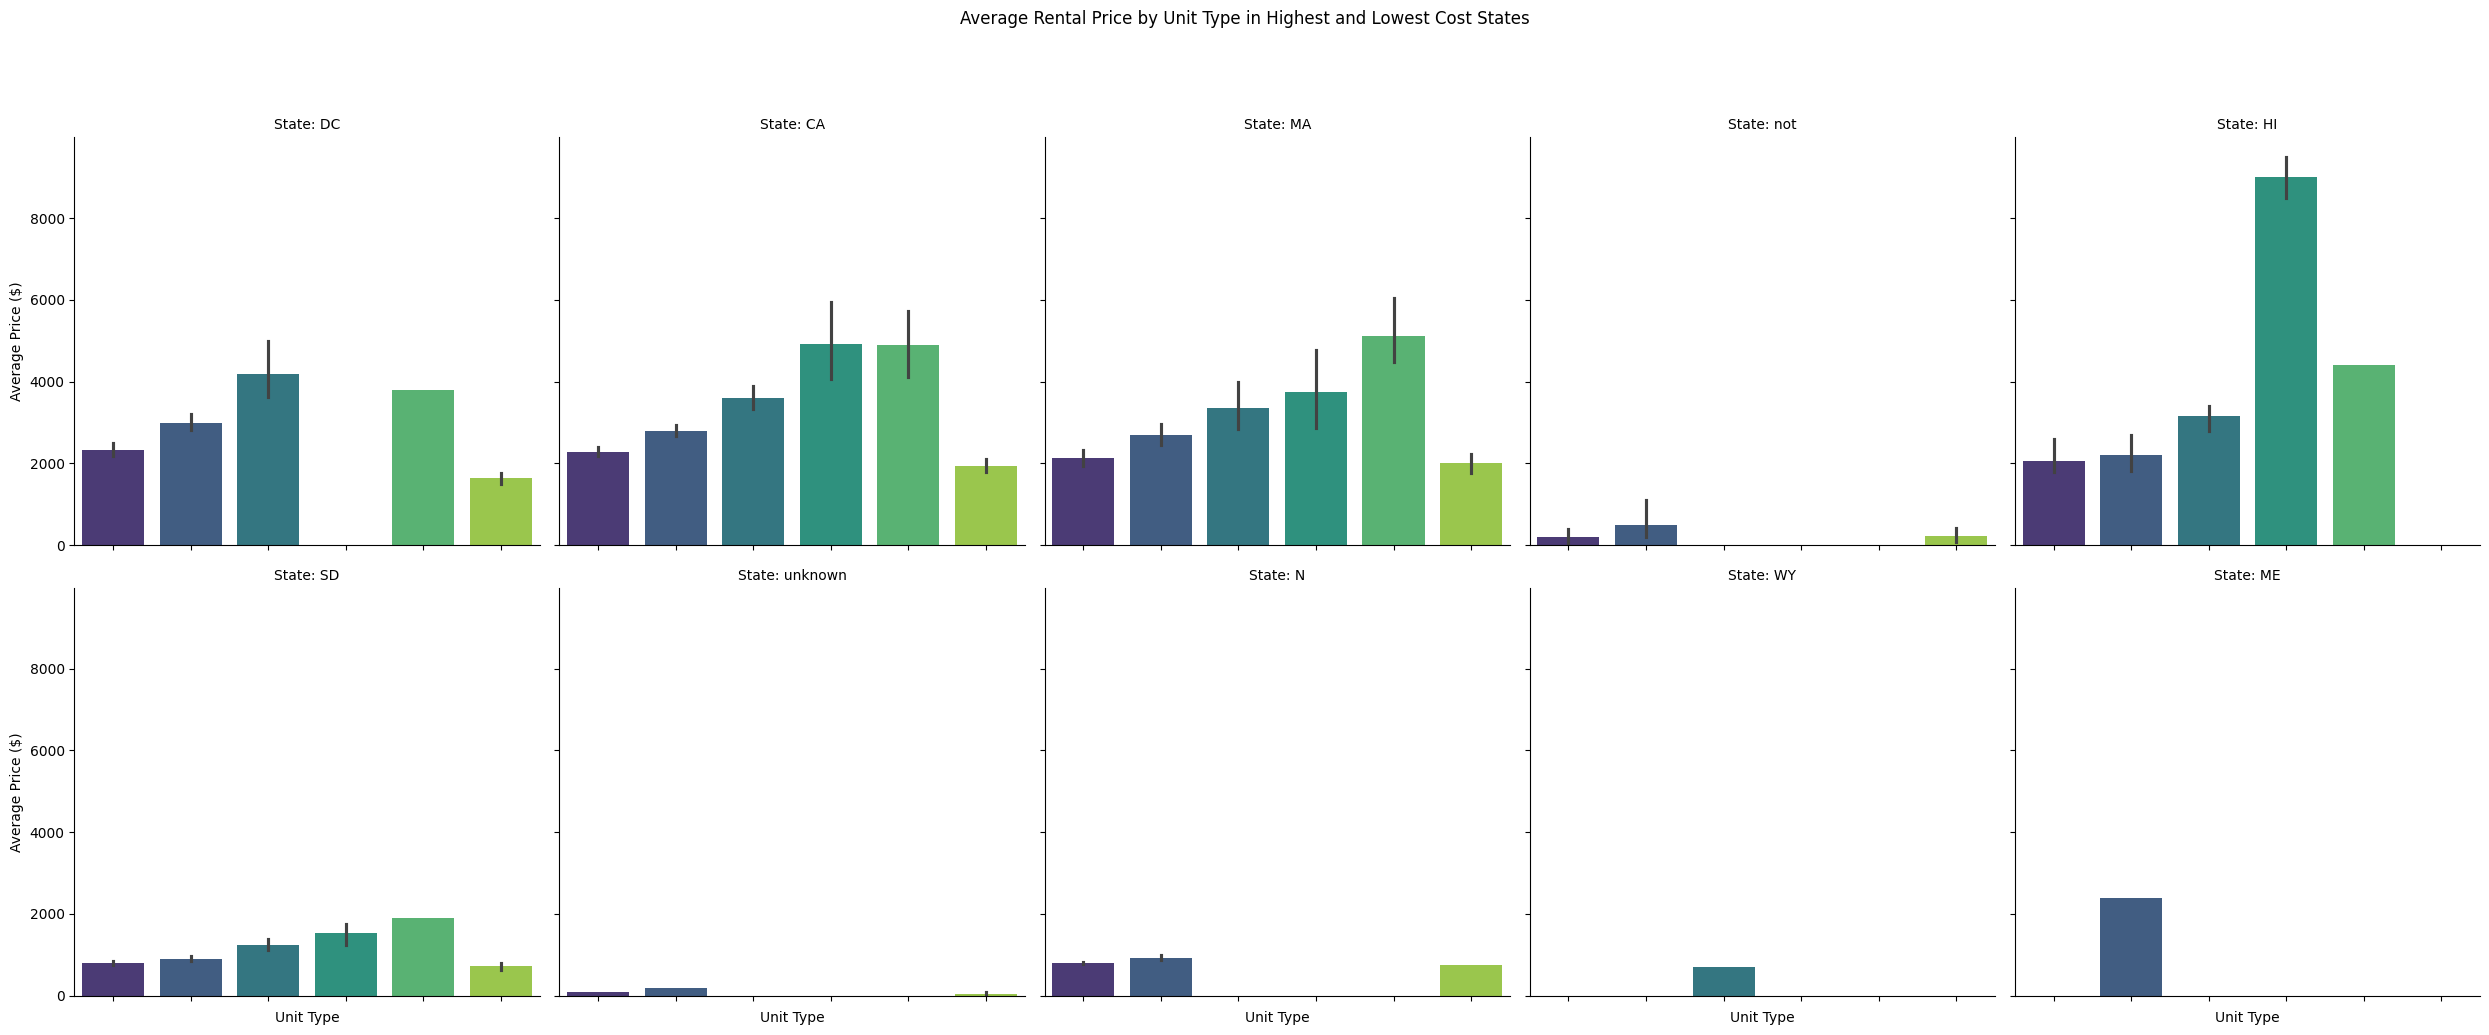

In [35]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load and Clean Data ---
# Ensure the CSV file is available and loaded
try:
    dataset = pd.read_csv("geocoded_data_complete.csv")
    # Replicate the cleaning from your notebook
    dataset.dropna(inplace=True)
    dataset.drop_duplicates(inplace=True)

    # --- Step 2: Analyze High and Low Rental Locations ---

    # --- Analysis for Cities ---
    avg_price_city = dataset.groupby('City')['Price'].mean().sort_values(ascending=False)
    print("--- 🏙 Average Rental Prices by City ---")
    print("\n💰 Top 10 Highest Rental Cities:")
    print(avg_price_city.head(10))
    print("\n💸 Top 10 Lowest Rental Cities:")
    print(avg_price_city.tail(10))

    # --- Analysis for States ---
    avg_price_state = dataset.groupby('State')['Price'].mean().sort_values(ascending=False)
    print("\n\n--- 🏞 Average Rental Prices by State ---")
    print("\n💰 Top 10 Highest Rental States:")
    print(avg_price_state.head(10))
    print("\n💸 Top 10 Lowest Rental States:")
    print(avg_price_state.tail(10))


    # --- Step 3: Visualize Rental Rates by Unit Type and State ---

    # For clarity, let's visualize the 5 highest and 5 lowest states
    top_5_states = avg_price_state.head(5).index.tolist()
    bottom_5_states = avg_price_state.tail(5).index.tolist()
    sample_states = top_5_states + bottom_5_states

    # Filter the dataset to only include these states
    df_sample = dataset[dataset['State'].isin(sample_states)]

    # Create the plot
    g = sns.catplot(
        data=df_sample,
        x='Unit_Type',
        y='Price',
        col='State',
        kind='bar',
        col_wrap=5,  # Arrange plots in a grid with 5 columns
        palette='viridis',
        order=sorted(df_sample['Unit_Type'].unique()) # Ensure consistent order
    )

    # Improve readability
    g.fig.suptitle('Average Rental Price by Unit Type in Highest and Lowest Cost States', y=1.03)
    g.set_axis_labels("Unit Type", "Average Price ($)")
    g.set_titles("State: {col_name}")
    g.set_xticklabels(rotation=45, horizontalalignment='right')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig('rental_rates_by_unit_type.png')
    plt.show()


except FileNotFoundError:
    print("Error: 'geocoded_data_complete.csv' not found.")
    print("Please make sure the data file is in the same directory as your notebook.")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16552\2544981629.py:15: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(train_plot_df[TARGET_COL]):


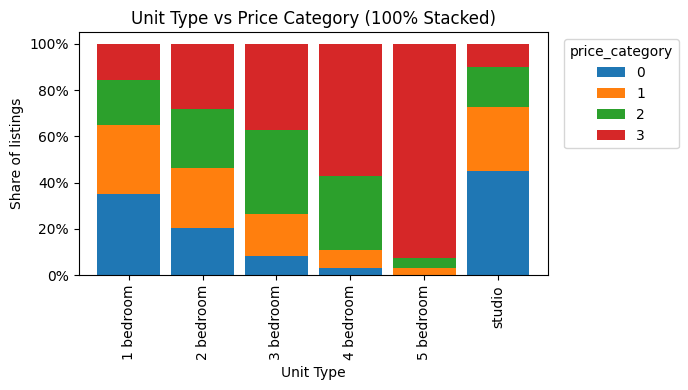

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Use your training frame
UNIT_COL   = "Unit_Type"
TARGET_COL = "price_category"

# Crosstab (counts) and convert to row-wise % (each unit_type sums to 100%)
ct  = pd.crosstab(train_plot_df[UNIT_COL], train_plot_df[TARGET_COL])
pct = ct.div(ct.sum(axis=1), axis=0).fillna(0)

# Keep a consistent price_category order if it's categorical
if pd.api.types.is_categorical_dtype(train_plot_df[TARGET_COL]):
    pct = pct.reindex(columns=list(train_plot_df[TARGET_COL].cat.categories))

ax = pct.plot(kind="bar", stacked=True, figsize=(7,4), width=0.85)
ax.set_title("Unit Type vs Price Category (100% Stacked)")
ax.set_xlabel("Unit Type")
ax.set_ylabel("Share of listings")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="price_category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [15]:
dataset.drop(['City', 'State','city_clean','state_clean','Price'], axis=1, inplace=True)


In [31]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

cramers_v_matrix = cramers_v_matrix.astype(float)

print(" Cramér’s V Association Matrix:\n")
print(cramers_v_matrix.round(3))

threshold = 0.6
strong_pairs = []

for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if j > i:  # avoid duplicate pairs
            val = cramers_v_matrix.loc[col1, col2]
            if val >= threshold:
                strong_pairs.append((col1, col2, val))

print("\n Strong Associations (Cramér’s V ≥ 0.6):")
if strong_pairs:
    for col1, col2, val in strong_pairs:
        print(f"  {col1} ↔ {col2} : {val:.3f}")
else:
    print("  None found above the threshold.")


 Cramér’s V Association Matrix:

                      Parking  Flooring  Laundry  Dishwasher  \
Parking                 1.000     0.358    0.524       0.499   
Flooring                0.358     1.000    0.565       0.491   
Laundry                 0.524     0.565    1.000       0.805   
Dishwasher              0.499     0.491    0.805       1.000   
Stainless_Appliances    0.020     0.142    0.066       0.077   
Cable                   0.043     0.115    0.144       0.127   
Internet                0.096     0.172    0.204       0.194   
Outdoor_Spaces          0.368     0.169    0.478       0.523   
AC                      0.407     0.450    0.562       0.586   
Pool                    0.116     0.110    0.237       0.202   
Fitness_Facilities      0.404     0.274    0.589       0.564   
State                   0.302     0.200    0.373       0.339   
City                    0.497     0.343    0.597       0.539   
rental_type             0.009     0.095    0.027       0.034   
Unit_Ty